[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/linear_algebra/03_linear_systems_and_direct_factorizations/first_principles.ipynb)

# Module 03 — Linear Systems and Direct Factorizations

## 1. Why This Module Exists

Almost every quantitative model ends at the same line of code: solve $Ax = b$. Regression,
Newton steps, Kalman updates, finite-element stress, Gaussian-process inference and graph
diffusion all reduce to it.

Two questions have to be answered before any arithmetic happens. Does a solution exist, and is
it unique? Both are settled by comparing the rank of $A$ with the rank of the augmented matrix.

The second half of the module is about *how*. Gaussian elimination is not a procedure to be
memorized; it is a **factorization**: $A$ is written as a product of triangular matrices, and
triangular systems are solved by substitution in $O(n^2)$ work.

That change of view is what makes the subject usable. Factor once at $O(n^3)$, then solve for
as many right-hand sides as you like at $O(n^2)$ each — and the factors themselves carry the
determinant, the inertia, the rank and the conditioning of $A$.

## 2. Intuition

Two equations in two unknowns are two lines in the plane. The solution is where they cross.

If the lines meet at a healthy angle, nudging one of them moves the crossing point by about as
much as you nudged. If they are nearly parallel, a nudge slides the crossing point a long way
along the shared direction.

That is the entire content of the condition number. It measures how close the rows of $A$ come
to being linearly dependent, and therefore how much an error in the data is magnified in the
answer.

Elimination is the second picture. Subtracting a multiple of one equation from another is a
**shear** of the plane: it does not move the intersection point, but it rotates one line until
it is axis-aligned. Repeating this until every line is axis-aligned is exactly $A = LU$.

Everything below is that picture in $n$ dimensions, plus the bookkeeping needed to keep the
shears from amplifying rounding error.

The first code cell is the notebook preamble. It fixes plotting defaults, seeds the single
random generator used everywhere in this notebook, and prints the two floating-point constants
that every later residual claim is measured against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

import scipy.linalg as sla

EPS = np.finfo(float).eps          # machine epsilon, 2^-52
U_ROUND = EPS / 2                  # unit roundoff u, 2^-53
print(f"machine epsilon eps = {EPS:.6e}   (2^-52 = {2.0**-52:.6e})")
print(f"unit roundoff     u = {U_ROUND:.6e}   (2^-53 = {2.0**-53:.6e})")

machine epsilon eps = 2.220446e-16   (2^-52 = 2.220446e-16)
unit roundoff     u = 1.110223e-16   (2^-53 = 1.110223e-16)


The register in [docs/notation.md](../../docs/notation.md) fixes
$\varepsilon_{\mathrm{mach}} = 2^{-52}$ and the unit roundoff $u = \tfrac12 \varepsilon_{\mathrm{mach}} = 2^{-53}$.
Every residual reported later is quoted as a multiple of $\varepsilon_{\mathrm{mach}}$.

The next cell draws the two-line picture for a well-conditioned and an ill-conditioned pair.

Left panel:

$$
x_1 + x_2 = 2, \qquad x_1 - x_2 = 0 .
$$

Right panel:

$$
x_1 + 2x_2 = 3, \qquad x_1 + 2.01\,x_2 = 3.01 .
$$

Both have the solution $(1,1)$. In each panel the second right-hand side is perturbed by
$0.01$ and the new intersection is drawn.

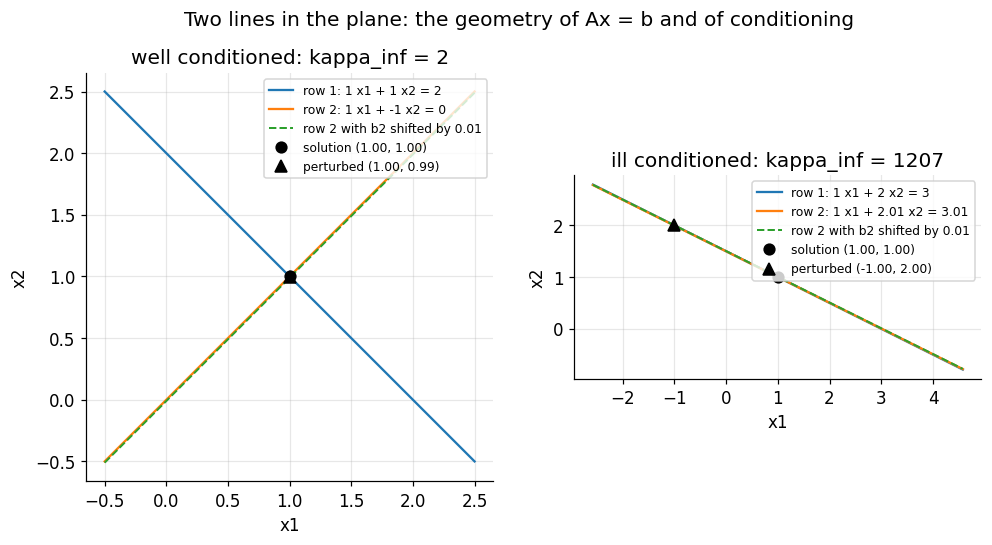

well conditioned   kappa_inf =    2.0000   rel. change in b = 0.00500   rel. change in x = 0.00500   amplification =     1.00
ill conditioned    kappa_inf = 1207.0100   rel. change in b = 0.00332   rel. change in x = 2.00000   amplification =   602.00


In [2]:
A_good = np.array([[1.0, 1.0], [1.0, -1.0]])
b_good = np.array([2.0, 0.0])
A_bad = np.array([[1.0, 2.0], [1.0, 2.01]])
b_bad = np.array([3.0, 3.01])
delta = np.array([0.0, 0.01])

fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.0))
for ax, A, b, name in [(axes[0], A_good, b_good, "well conditioned"),
                       (axes[1], A_bad, b_bad, "ill conditioned")]:
    x0 = np.linalg.solve(A, b)
    x1 = np.linalg.solve(A, b + delta)
    span = max(1.5, 1.6 * np.linalg.norm(x1 - x0))
    t = np.linspace(x0[0] - span, x0[0] + span, 200)
    for i, style in enumerate(["-", "-"]):
        ax.plot(t, (b[i] - A[i, 0] * t) / A[i, 1], style, lw=1.5,
                label=f"row {i + 1}: {A[i, 0]:g} x1 + {A[i, 1]:g} x2 = {b[i]:g}")
    ax.plot(t, (b[1] + delta[1] - A[1, 0] * t) / A[1, 1], "--", lw=1.3,
            label="row 2 with b2 shifted by 0.01")
    ax.plot(*x0, "ko", ms=7, label=f"solution ({x0[0]:.2f}, {x0[1]:.2f})")
    ax.plot(*x1, "k^", ms=8, label=f"perturbed ({x1[0]:.2f}, {x1[1]:.2f})")
    ax.set_aspect("equal")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_title(f"{name}: kappa_inf = {np.linalg.cond(A, np.inf):.4g}")
    ax.legend(fontsize=8, loc="upper right")
fig.suptitle("Two lines in the plane: the geometry of Ax = b and of conditioning")
plt.show()

for A, b, name in [(A_good, b_good, "well conditioned"), (A_bad, b_bad, "ill conditioned")]:
    x0 = np.linalg.solve(A, b)
    x1 = np.linalg.solve(A, b + delta)
    rel_b = np.linalg.norm(delta, np.inf) / np.linalg.norm(b, np.inf)
    rel_x = np.linalg.norm(x1 - x0, np.inf) / np.linalg.norm(x0, np.inf)
    print(f"{name:18s} kappa_inf = {np.linalg.cond(A, np.inf):9.4f}"
          f"   rel. change in b = {rel_b:.5f}   rel. change in x = {rel_x:.5f}"
          f"   amplification = {rel_x / rel_b:8.2f}")

The left crossing barely moves: a $0.5$ percent change in $b$ produces a $0.5$ percent change
in $x$, an amplification near $1$.

The right crossing jumps from $(1,1)$ to $(-1,2)$. The same size of perturbation is amplified
about $602$ times, and the printed $\kappa_\infty = 1207.01$ is the ceiling on that
amplification — a bound that Theorem 4.10 makes precise and Example 6.8 recomputes by hand.

The geometry says why: the two lines in the right panel differ in slope by $0.5$ percent, so
they are almost the same line, and their intersection is almost undetermined.

## 3. Definitions

Throughout, $A \in \mathbb{R}^{m \times n}$, vectors are columns, and $A^\top$ is the
transpose. Conventions follow [the notation register](../../docs/notation.md): norms are
written $\lVert x \rVert$, factorizations $A = LU$ and $A = LL^\top$, and the condition number
$\kappa(A) = \lVert A \rVert \, \lVert A^{-1} \rVert$ in whichever norm is named.

### Definition 3.1 — Linear system and solution set

Given $A \in \mathbb{R}^{m \times n}$ and $b \in \mathbb{R}^m$, the **solution set** of
$Ax = b$ is

$$
\mathcal{S}(A, b) = \lbrace x \in \mathbb{R}^n : Ax = b \rbrace .
$$

Writing $A = [\,a_1 \; \cdots \; a_n\,]$ by columns, $Ax = \sum_j x_j a_j$, so the system asks
whether $b$ is a linear combination of the columns of $A$.

### Definition 3.2 — The four fundamental subspaces

For $A \in \mathbb{R}^{m \times n}$:

- $\operatorname{Col}(A) = \lbrace Ax : x \in \mathbb{R}^n \rbrace \subseteq \mathbb{R}^m$, the **column space**;
- $\operatorname{Null}(A) = \lbrace x : Ax = 0 \rbrace \subseteq \mathbb{R}^n$, the **null space**;
- $\operatorname{Row}(A) = \operatorname{Col}(A^\top) \subseteq \mathbb{R}^n$, the **row space**;
- $\operatorname{Null}(A^\top) \subseteq \mathbb{R}^m$, the **left null space**.

The **rank** is $r = \dim \operatorname{Col}(A)$.

### Definition 3.3 — Triangular matrices and leading principal submatrices

$L$ is **lower triangular** when $l_{ij} = 0$ for $j \gt i$, and **unit** lower triangular when
in addition $l_{ii} = 1$. $U$ is **upper triangular** when $u_{ij} = 0$ for $i \gt j$.

For $A \in \mathbb{R}^{n \times n}$ and $1 \le k \le n$, the **leading principal submatrix**
$A_k \in \mathbb{R}^{k \times k}$ is the top-left $k \times k$ block, $(A_k)_{ij} = a_{ij}$ for
$i, j \le k$.

### Definition 3.4 — The four direct factorizations

For $A \in \mathbb{R}^{n \times n}$:

- **LU**: $A = LU$ with $L$ unit lower triangular and $U$ upper triangular.
- **PLU**: $PA = LU$ with $P$ a permutation matrix.
- **Cholesky**: $A = LL^\top$ with $L$ lower triangular and $l_{ii} \gt 0$.
- **$LDL^\top$**: $A = LDL^\top$ with $L$ unit lower triangular and $D$ diagonal.

A **permutation matrix** is a matrix whose columns are the standard basis vectors in some
order; it satisfies $P^\top P = I$, so $P^{-1} = P^\top$.

### Definition 3.5 — Positive definiteness and inertia

A symmetric $A \in \mathbb{R}^{n \times n}$ is **positive definite** (SPD) when
$x^\top A x \gt 0$ for every $x \neq 0$, and **positive semidefinite** when
$x^\top A x \ge 0$ for every $x$.

The **inertia** of a symmetric $A$ is the triple $(n_+, n_-, n_0)$ counting its positive,
negative and zero eigenvalues.

### Definition 3.6 — Condition number

For an induced matrix norm and nonsingular $A$,

$$
\kappa(A) = \lVert A \rVert \, \lVert A^{-1} \rVert \; \ge \; 1 .
$$

The subscript names the norm: $\kappa_\infty$ uses the maximum absolute row sum,
$\kappa_2$ the largest singular value over the smallest. It is a property of the **problem**,
not of any algorithm.

### Definition 3.7 — Backward error, forward error, growth factor

Let $\hat{x}$ be a computed solution of $Ax = b$ and $r = b - A\hat{x}$ its residual.

- The **forward error** is $\lVert \hat{x} - x \rVert / \lVert x \rVert$.
- The **normwise backward error** is
  $\eta(\hat{x}) = \min \lbrace \varepsilon : (A + \delta A)\hat{x} = b, \; \lVert \delta A \rVert \le \varepsilon \lVert A \rVert \rbrace$.
- An algorithm is **backward stable** when $\eta(\hat{x}) = O(u)$ for every input.

Writing $a_{ij}^{(k)}$ for the entries after $k$ elimination steps, the **growth factor** is

$$
\rho = \frac{\max_{i,j,k} \lvert a_{ij}^{(k)} \rvert}{\max_{i,j} \lvert a_{ij} \rvert} .
$$

## 4. Main Results

Proposition 4.1 and Theorems 4.2 and 4.3 settle *which* systems have solutions and what the
solution set looks like.

Theorems 4.4 to 4.7 are the factorization theorems the module is named after: when $A = LU$
exists and is unique, why permuting rows always rescues it, and what symmetry plus
definiteness buys. Theorems 4.8 and 4.9 extend the same elimination idea to blocks and to
low-rank updates.

Theorems 4.10 to 4.12 answer the numerical question: how far can the computed answer be from
the true one, and whose fault is it.

### Proposition 4.1 — Row rank equals column rank

For every $A \in \mathbb{R}^{m \times n}$,

$$
\dim \operatorname{Col}(A) = \dim \operatorname{Col}(A^\top) .
$$

**Hypotheses.** None beyond $A$ being a matrix over a field. The statement is not obvious: the
two spaces live in different ambient spaces, $\mathbb{R}^m$ and $\mathbb{R}^n$.

Proved as Proof 5.1.

### Theorem 4.2 — Solvability and the structure of the solution set

Let $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$, $r = \operatorname{rank}(A)$ and
$[A \mid b]$ the augmented matrix.

$$
\mathcal{S}(A,b) \neq \varnothing
\iff b \in \operatorname{Col}(A)
\iff \operatorname{rank}([A \mid b]) = r .
$$

If $\mathcal{S}(A,b) \neq \varnothing$ and $x_p$ is any solution, then

$$
\mathcal{S}(A,b) = x_p + \operatorname{Null}(A),
$$

an affine subspace of dimension $n - r$. The solution is unique exactly when $r = n$.

**Hypotheses.** None. The equivalence with the augmented rank is the Rouché-Capelli form and
uses Proposition 4.1 only through the fact that rank is well defined.

Proved as Proof 5.2.

### Theorem 4.3 — The four fundamental subspaces

For every $A \in \mathbb{R}^{m \times n}$,

$$
\operatorname{Null}(A) = \operatorname{Col}(A^\top)^{\perp}, \qquad
\operatorname{Null}(A^\top) = \operatorname{Col}(A)^{\perp},
$$

and consequently

$$
\mathbb{R}^n = \operatorname{Col}(A^\top) \oplus \operatorname{Null}(A), \qquad
\mathbb{R}^m = \operatorname{Col}(A) \oplus \operatorname{Null}(A^\top),
$$

with dimensions $r + (n-r) = n$ and $r + (m-r) = m$.

**Hypotheses.** Real entries and the standard inner product. Over $\mathbb{C}$ the same holds
with $A^{\ast}$ in place of $A^\top$; with $A^\top$ it is false, because $x^\top x$ can vanish
for $x \neq 0$.

Proved as Proof 5.3.

### Theorem 4.4 — LU factorization: existence and uniqueness

Let $A \in \mathbb{R}^{n \times n}$ be nonsingular. Then

$$
\boxed{A = LU \text{ with } L \text{ unit lower triangular} \iff A_k \text{ is nonsingular for } k = 1, \dots, n-1,}
$$

and when the factorization exists it is unique.

**Interpretation.** Elimination without row swaps succeeds precisely when it never meets a zero
pivot, and a zero pivot at step $k+1$ is exactly the statement that $A_k$ is singular. The
factorization is a record of the elimination, so it inherits its failure mode.

**Hypotheses.** Nonsingularity of $A$ is needed for the forward implication and for uniqueness:
$A = \left[\begin{smallmatrix}0 & 0 \\ 0 & 1\end{smallmatrix}\right]$ has $A_1$ singular yet
$A = IA$ is an LU factorization, and it is not unique, since $L$ may carry any $l_{21}$.
Nonsingularity of every $A_k$ for $k \le n-1$ is needed for existence:
$\left[\begin{smallmatrix}0 & 1 \\ 1 & 0\end{smallmatrix}\right]$ is nonsingular and has no LU
factorization at all, as Example 6.3 shows and Section 7.3 runs.

**On the determinant form.** The classical statement replaces "$A_k$ nonsingular" with
$\det A_k \neq 0$. The two are the same condition; this module states it without determinants
so that nothing here depends on machinery developed elsewhere.

Proved as Proof 5.4.

### Theorem 4.5 — PA = LU always exists, and partial pivoting bounds the multipliers

For every $A \in \mathbb{R}^{n \times n}$ there exist a permutation matrix $P$, a unit lower
triangular $L$ and an upper triangular $U$ with

$$
\boxed{PA = LU .}
$$

If $P$ is chosen by **partial pivoting** — at step $k$, swap in the row with the largest
$\lvert a_{ik}^{(k)} \rvert$ for $i \ge k$ — then every multiplier satisfies

$$
\lvert l_{ij} \rvert \le 1 .
$$

**Interpretation.** Row order is a free choice that costs nothing and removes the only failure
mode of Theorem 4.4. This is why every production solver factors $PA$, never $A$.

**Hypotheses.** None: squareness only. $A$ may be singular, in which case some $u_{kk} = 0$.

Proved as Proof 5.5.

### Theorem 4.6 — Cholesky factorization

Let $A \in \mathbb{R}^{n \times n}$ be symmetric. Then

$$
\boxed{A \text{ is positive definite} \iff A = LL^\top \text{ with } L \text{ lower triangular and } l_{ii} \gt 0,}
$$

and in that case $L$ is unique.

**Interpretation.** $L$ is a matrix square root adapted to the coordinate order. It costs
$\tfrac13 n^3$ flops, half of LU, needs no pivoting for stability, and its very existence is a
certificate of positive definiteness.

**Hypotheses.** Symmetry is what makes the two triangular factors transposes of each other.
Positive definiteness is what keeps every $a_{kk} - \sum_j l_{kj}^2$ strictly positive so the
square roots are real; drop it and the algorithm halts, as Example 6.5 and Section 7.3 show.

Proved as Proof 5.6.

### Theorem 4.7 — Positive pivots, $LDL^\top$, and Sylvester's criterion

Let $A \in \mathbb{R}^{n \times n}$ be symmetric. The following are equivalent.

1. $A$ is positive definite.
2. $A = LDL^\top$ with $L$ unit lower triangular and every $d_i \gt 0$.
3. Gaussian elimination on $A$ without row swaps runs to completion with $n$ strictly positive
   pivots.

**Corollary 4.7a (Sylvester's criterion).** A symmetric $A$ is positive definite if and only if
$\det A_k \gt 0$ for every $k = 1, \dots, n$.

**Interpretation.** Definiteness is visible in the pivots, which elimination produces anyway.
There is no need to compute an eigenvalue to test it.

**Hypotheses.** Symmetry throughout. Without it the pivots say nothing about definiteness:
$\left[\begin{smallmatrix}1 & -4 \\ 0 & 1\end{smallmatrix}\right]$ has pivots $1, 1$ and
$x^\top A x$ takes negative values.

A symmetric **indefinite** $A$ need not have any $LDL^\top$ with diagonal $D$: the matrix
$\left[\begin{smallmatrix}0 & 1 \\ 1 & 0\end{smallmatrix}\right]$ has none, because $d_1$ would
have to be $0$ and then $l_{21}d_1 = 1$ is unsolvable. The general symmetric case needs
symmetric pivoting with $2 \times 2$ blocks in $D$, which is the Bunch-Kaufman factorization
$PAP^\top = LDL^\top$.

Proved as Proof 5.7.

### Theorem 4.8 — Block elimination and the Schur complement

Let

$$
M = \begin{bmatrix} A & B \\ C & D \end{bmatrix}
$$

with $A \in \mathbb{R}^{p \times p}$ nonsingular, and set $S = D - CA^{-1}B$, the **Schur
complement** of $A$ in $M$. Then

$$
\boxed{M = \begin{bmatrix} I & 0 \\ CA^{-1} & I \end{bmatrix}
\begin{bmatrix} A & 0 \\ 0 & S \end{bmatrix}
\begin{bmatrix} I & A^{-1}B \\ 0 & I \end{bmatrix} .}
$$

Consequences:

- $M$ is nonsingular if and only if $S$ is nonsingular;
- $\det M = \det A \cdot \det S$;
- if $M$ is symmetric positive definite then so are $A$ and $S$.

**Interpretation.** Eliminating a block of variables leaves a smaller system whose matrix is
the Schur complement. Cholesky is this statement applied with $p = 1$ at every step.

**Hypotheses.** $A$ must be nonsingular; otherwise $A^{-1}$ does not exist and the elimination
cannot start. Symmetry of $M$ is needed only for the third consequence.

Proved as Proof 5.8.

### Theorem 4.9 — Sherman-Morrison-Woodbury

Let $A \in \mathbb{R}^{n \times n}$ and $C \in \mathbb{R}^{k \times k}$ be nonsingular, and let
$U \in \mathbb{R}^{n \times k}$, $V \in \mathbb{R}^{k \times n}$. If $C^{-1} + VA^{-1}U$ is
nonsingular, then $A + UCV$ is nonsingular and

$$
\boxed{(A + UCV)^{-1} = A^{-1} - A^{-1}U\left(C^{-1} + VA^{-1}U\right)^{-1}VA^{-1} .}
$$

The rank-one case $C = 1$, $U = u$, $V = v^\top$ is **Sherman-Morrison**:

$$
(A + uv^\top)^{-1} = A^{-1} - \frac{A^{-1}uv^\top A^{-1}}{1 + v^\top A^{-1} u},
\qquad 1 + v^\top A^{-1} u \neq 0 .
$$

**Interpretation.** A rank-$k$ change to $A$ costs one $k \times k$ inverse, not an
$n \times n$ one. With $k \ll n$ the update is $O(n^2)$ instead of $O(n^3)$.

**Hypotheses.** The inner matrix $C^{-1} + VA^{-1}U$ must be nonsingular; when it is singular,
$A + UCV$ is singular too and no inverse exists.

Proved as Proof 5.9.

### Theorem 4.10 — Perturbation bound and the condition number

Let $A$ be nonsingular, $Ax = b$ with $b \neq 0$, and let $\delta A$, $\delta b$ satisfy
$\lVert A^{-1} \rVert \, \lVert \delta A \rVert \lt 1$. Then $A + \delta A$ is nonsingular, and
the solution $x + \delta x$ of $(A + \delta A)(x + \delta x) = b + \delta b$ obeys

$$
\boxed{\frac{\lVert \delta x \rVert}{\lVert x \rVert} \;\le\;
\frac{\kappa(A)}{1 - \kappa(A)\,\lVert \delta A \rVert / \lVert A \rVert}
\left( \frac{\lVert \delta A \rVert}{\lVert A \rVert} + \frac{\lVert \delta b \rVert}{\lVert b \rVert} \right) .}
$$

**Interpretation.** The relative error in the answer is at most $\kappa(A)$ times the relative
error in the data. Meaning: $\kappa$ is an amplification factor. Consequence: with
$\kappa(A) \approx 10^k$ and data accurate to working precision, roughly $k$ decimal digits of
the answer are unrecoverable — *by any algorithm whatsoever*.

> **The digit-loss rule, stated correctly.** If $\kappa(A) \approx 10^k$ then a
> **backward-stable** algorithm loses about $k$ decimal digits relative to working precision,
> and that is the best any algorithm can do. A backward-*unstable* algorithm loses more, with
> no bound: its computed answer solves a problem far from the one posed, so the loss is not
> governed by $\kappa$ at all.

**Hypotheses.** $\lVert A^{-1} \rVert \lVert \delta A \rVert \lt 1$ keeps $A + \delta A$
nonsingular; without it the perturbed system may have no solution, and the bound is vacuous.

Proved as Proof 5.10.

### Theorem 4.11 — The backward error of a computed solution

Let $A \in \mathbb{R}^{n \times n}$, $b \in \mathbb{R}^n$, and let $\hat{x} \neq 0$ be any
vector with residual $r = b - A\hat{x}$. In the $2$-norm,

$$
\boxed{\min \lbrace \lVert \delta A \rVert_2 : (A + \delta A)\hat{x} = b \rbrace
= \frac{\lVert r \rVert_2}{\lVert \hat{x} \rVert_2},}
$$

and the minimum is attained by the rank-one perturbation
$\delta A = r\hat{x}^\top / \lVert \hat{x} \rVert_2^2$.

**Interpretation.** The residual is not a measure of accuracy; it is a measure of backward
error. A small relative residual $\lVert r \rVert / (\lVert A \rVert \lVert \hat{x} \rVert)$
says the computed vector solves a nearby problem exactly, and says nothing on its own about
distance to $x$ — Theorem 4.10 supplies the missing factor $\kappa(A)$.

**Hypotheses.** Only $\hat{x} \neq 0$. No assumption about how $\hat{x}$ was produced.

Proved as Proof 5.11.

### Theorem 4.12 (cited, not proved here) — Wilkinson's backward-error bound for GEPP

Let $\hat{L}, \hat{U}$ be the factors computed in floating point by Gaussian elimination with
partial pivoting, and $\hat{x}$ the solution obtained from them. Then $\hat{x}$ satisfies
$(A + \delta A)\hat{x} = b$ exactly, with

$$
\lVert \delta A \rVert_\infty \;\le\; c\, n^3 \rho \, u \, \lVert A \rVert_\infty ,
$$

where $\rho$ is the growth factor of Definition 3.7 and $c$ is a small constant. Golub and Van
Loan quote $c = 8$.

The proof has two halves. The first is the elementwise Wilkinson bound
$\lvert \delta A \rvert \le \gamma_{3n} \lvert \hat{L} \rvert \lvert \hat{U} \rvert$ with
$\gamma_{k} = ku/(1-ku)$, which is an accounting of rounding errors through the whole
elimination; that half is cited. The second half is the bound

$$
\bigl\lVert \, \lvert \hat{L} \rvert \, \lvert \hat{U} \rvert \, \bigr\rVert_\infty
\;\le\; n^2 \rho \, \lVert A \rVert_\infty ,
$$

which follows from partial pivoting alone and **is** proved here, as Proof 5.12. Multiplying
the two halves and using $\gamma_{3n} \approx 3nu$ gives the $n^3$.

> **Why the exponent matters.** Writing this bound as $3nu\rho$ — dropping the $n^2$ from
> $\lVert \lvert \hat{L} \rvert \lvert \hat{U} \rvert \rVert_\infty$ — understates it by two
> powers of $n$. At $n = 1000$ that is a factor of $10^6$.

**Growth factor bounds.** Partial pivoting admits $\rho \le 2^{n-1}$, attained by the Wilkinson
matrix of Section 7.5. Complete pivoting, which searches the whole remaining submatrix, admits
the much smaller bound $\rho \le n^{1/2}\bigl(2\cdot3^{1/2}\cdots n^{1/(n-1)}\bigr)^{1/2}$, at
the cost of $O(n^3)$ comparisons.

Sources: Higham, *Accuracy and Stability of Numerical Algorithms*, 2nd ed., Theorem 9.3 and
equation (9.14); Golub and Van Loan, *Matrix Computations*, 4th ed., section 3.4.6;
Wilkinson, *The Algebraic Eigenvalue Problem*, section 8.

## 5. Derivations and Proofs

### Proof 5.1 (of Proposition 4.1, row rank equals column rank)

Let $r = \dim \operatorname{Col}(A)$ and pick a basis $c_1, \dots, c_r$ of
$\operatorname{Col}(A)$. Collect it in $C = [\, c_1 \; \cdots \; c_r \,] \in \mathbb{R}^{m \times r}$.

Every column $a_j$ of $A$ lies in $\operatorname{Col}(A)$, so $a_j = C f_j$ for a unique
$f_j \in \mathbb{R}^{r}$. Assembling the $f_j$ as the columns of
$F \in \mathbb{R}^{r \times n}$,

$$
A = CF .
$$

Transposing gives $A^\top = F^\top C^\top$, so every column of $A^\top$ is a combination of the
$r$ columns of $F^\top$. Hence

$$
\dim \operatorname{Col}(A^\top) \le r = \dim \operatorname{Col}(A) .
$$

The inequality holds for every matrix, so applying it to $A^\top$ gives
$\dim \operatorname{Col}(A) \le \dim \operatorname{Col}(A^\top)$. The two inequalities force
equality. $\blacksquare$

### Proof 5.2 (of Theorem 4.2, solvability and solution structure)

**Existence.** $Ax = b$ has a solution exactly when $b$ is a linear combination of the columns
of $A$, which is the statement $b \in \operatorname{Col}(A)$.

Adjoining $b$ to the columns of $A$ cannot decrease the span, and it increases the dimension
by one precisely when $b \notin \operatorname{Col}(A)$. Hence

$$
b \in \operatorname{Col}(A) \iff \operatorname{rank}([A \mid b]) = \operatorname{rank}(A) .
$$

**Structure.** Let $x_p$ satisfy $Ax_p = b$.

If $Ax = b$ then $A(x - x_p) = 0$, so $x \in x_p + \operatorname{Null}(A)$.

Conversely if $x = x_p + z$ with $Az = 0$ then $Ax = b + 0 = b$.

Therefore $\mathcal{S}(A,b) = x_p + \operatorname{Null}(A)$, a translate of a subspace of
dimension $n - r$ by the rank-nullity theorem.

**Uniqueness.** The translate is a single point exactly when $\operatorname{Null}(A) = \lbrace 0 \rbrace$,
that is when $n - r = 0$. $\blacksquare$

### Proof 5.3 (of Theorem 4.3, the four subspaces)

Write the rows of $A$ as $r_1^\top, \dots, r_m^\top$.

**$\operatorname{Null}(A) \subseteq \operatorname{Col}(A^\top)^{\perp}$.** If $Ax = 0$ then
every entry of $Ax$ vanishes, that is $r_i^\top x = 0$ for all $i$. Any
$y \in \operatorname{Col}(A^\top)$ is $y = \sum_i c_i r_i$, so $y^\top x = \sum_i c_i r_i^\top x = 0$.

**$\operatorname{Col}(A^\top)^{\perp} \subseteq \operatorname{Null}(A)$.** If $x$ is orthogonal
to every element of $\operatorname{Col}(A^\top)$ then in particular $r_i^\top x = 0$ for each
$i$, which is exactly $Ax = 0$.

The two inclusions give $\operatorname{Null}(A) = \operatorname{Col}(A^\top)^{\perp}$, and
applying the result to $A^\top$ gives $\operatorname{Null}(A^\top) = \operatorname{Col}(A)^{\perp}$.

**Direct sums.** For any subspace $W \subseteq \mathbb{R}^n$ one has
$\mathbb{R}^n = W \oplus W^{\perp}$, so with $W = \operatorname{Col}(A^\top)$,

$$
\mathbb{R}^n = \operatorname{Col}(A^\top) \oplus \operatorname{Null}(A) .
$$

The dimension count $\dim \operatorname{Col}(A^\top) = r$ uses Proposition 4.1, proved in
Proof 5.1; without it the row space would have no reason to have the same dimension as the
column space and the count $r + (n-r) = n$ would not close. $\blacksquare$

### Proof 5.4 (of Theorem 4.4, LU existence and uniqueness)

Both directions are proved. The audit-worthy half is the first one, which the constructive
argument alone does not give.

**Necessity.** Suppose $A = LU$ with $A$ nonsingular and $L$ unit lower triangular.

For $i, j \le k$ the product entry is $(LU)_{ij} = \sum_m l_{im} u_{mj}$, and a term survives
only when $m \le i$ and $m \le j$, hence only when $m \le k$. Therefore the leading blocks
multiply on their own:

$$
A_k = L_k U_k , \qquad k = 1, \dots, n .
$$

Since $A$ is nonsingular and $L$ is unit triangular, $U = L^{-1}A$ is nonsingular, so every
$u_{ii} \neq 0$. Then $U_k$ is upper triangular with nonzero diagonal, hence nonsingular, and
$L_k$ is unit lower triangular, hence nonsingular. A product of nonsingular matrices is
nonsingular, so $A_k$ is nonsingular for every $k$ — in particular for $k \le n-1$.

**Sufficiency.** Induct on $n$. For $n = 1$, $A = [a_{11}]$ with $a_{11} \neq 0$, and
$L = [1]$, $U = [a_{11}]$.

Assume the claim for size $n-1$ and let $A \in \mathbb{R}^{n \times n}$ be nonsingular with
$A_1, \dots, A_{n-1}$ nonsingular. Partition

$$
A = \begin{bmatrix} A_{n-1} & b \\ c^\top & a_{nn} \end{bmatrix} .
$$

By the inductive hypothesis $A_{n-1} = L_{n-1}U_{n-1}$ uniquely, and both factors are
nonsingular because $A_{n-1}$ is.

Seek

$$
L = \begin{bmatrix} L_{n-1} & 0 \\ \ell^\top & 1 \end{bmatrix}, \qquad
U = \begin{bmatrix} U_{n-1} & v \\ 0^\top & u_{nn} \end{bmatrix} .
$$

Multiplying out and matching blocks gives four equations:

$$
L_{n-1}U_{n-1} = A_{n-1}, \qquad
L_{n-1} v = b, \qquad
U_{n-1}^\top \ell = c, \qquad
\ell^\top v + u_{nn} = a_{nn} .
$$

The first holds by hypothesis. The second and third are triangular systems with nonsingular
matrices, so $v$ and $\ell$ exist and are unique. The fourth defines $u_{nn}$ uniquely.

**Uniqueness.** Suppose $A = L_1U_1 = L_2U_2$ with both $L_i$ unit lower triangular. Since $A$
is nonsingular, so are all four factors, and

$$
L_2^{-1}L_1 = U_2U_1^{-1} .
$$

The left side is unit lower triangular; the right side is upper triangular. A matrix that is
both is diagonal, and its diagonal is that of the left side, namely all ones. So both sides
equal $I$, giving $L_1 = L_2$ and $U_1 = U_2$. $\blacksquare$

**Where the failure lives.** If $A_k$ is singular for some $k \le n-1$, the third equation
$U_k^\top \ell = c$ has a singular matrix and the construction stops. Concretely, elimination
reaches a zero pivot.

### Proof 5.5 (of Theorem 4.5, PA = LU with partial pivoting)

Induct on $n$. For $n = 1$ take $P = L = [1]$ and $U = A$.

**Step 1 — choose the pivot.** Let $p$ be an index maximizing $\lvert a_{i1} \rvert$ over
$i = 1, \dots, n$, and let $\Pi_1$ be the permutation swapping rows $1$ and $p$. Write

$$
\Pi_1 A = \begin{bmatrix} \alpha & w^\top \\ v & A_{22} \end{bmatrix},
\qquad \lvert v_i \rvert \le \lvert \alpha \rvert \text{ for all } i .
$$

**Step 2 — eliminate.** Put $\ell = v/\alpha$ if $\alpha \neq 0$, and $\ell = 0$ otherwise; in
the second case $v = 0$ as well, because $\alpha$ was the largest entry in modulus. Either way
$\alpha \ell = v$ and $\lVert \ell \rVert_\infty \le 1$. Then

$$
\begin{bmatrix} 1 & 0 \\ -\ell & I \end{bmatrix} \Pi_1 A
= \begin{bmatrix} \alpha & w^\top \\ 0 & A_{22} - \ell w^\top \end{bmatrix} .
$$

**Step 3 — recurse.** By the inductive hypothesis there are $\tilde{P}, \tilde{L}, \tilde{U}$
with $\tilde{P}(A_{22} - \ell w^\top) = \tilde{L}\tilde{U}$ and $\tilde{L}$ unit lower
triangular with entries bounded by $1$ in modulus.

**Step 4 — assemble.** Set

$$
P = \begin{bmatrix} 1 & 0 \\ 0 & \tilde{P} \end{bmatrix} \Pi_1, \qquad
L = \begin{bmatrix} 1 & 0 \\ \tilde{P}\ell & \tilde{L} \end{bmatrix}, \qquad
U = \begin{bmatrix} \alpha & w^\top \\ 0 & \tilde{U} \end{bmatrix} .
$$

Then

$$
PA = \begin{bmatrix} \alpha & w^\top \\ \tilde{P}v & \tilde{P}A_{22} \end{bmatrix},
\qquad
LU = \begin{bmatrix} \alpha & w^\top \\ \alpha \tilde{P}\ell & \tilde{P}\ell w^\top + \tilde{L}\tilde{U} \end{bmatrix} .
$$

The lower-left blocks agree because $\alpha\ell = v$. The lower-right blocks agree because
$\tilde{L}\tilde{U} = \tilde{P}(A_{22} - \ell w^\top) = \tilde{P}A_{22} - \tilde{P}\ell w^\top$.
Hence $PA = LU$.

**Multiplier bound.** Every entry of $L$ below the diagonal is an entry of some $\tilde{P}\ell$,
and $\lVert \ell \rVert_\infty \le 1$ by the pivot choice, so
$\lvert l_{ij} \rvert \le 1$. $\blacksquare$

### Proof 5.6 (of Theorem 4.6, Cholesky)

**Sufficiency ($LL^\top \Rightarrow$ positive definite).** If $A = LL^\top$ with $l_{ii} \gt 0$
then $L$ is nonsingular, so for $x \neq 0$,

$$
x^\top A x = x^\top L L^\top x = \lVert L^\top x \rVert_2^2 \gt 0 .
$$

**Necessity ($A$ positive definite $\Rightarrow LL^\top$).** Induct on $n$.

For $n = 1$, $a_{11} = e_1^\top A e_1 \gt 0$, so $L = [\sqrt{a_{11}}\,]$ works.

For the step, partition

$$
A = \begin{bmatrix} a_{11} & v^\top \\ v & B \end{bmatrix},
\qquad a_{11} \gt 0 ,
$$

and set $l_{11} = \sqrt{a_{11}}$, $\ell = v/l_{11}$. Matching blocks in

$$
\begin{bmatrix} l_{11} & 0 \\ \ell & L_B \end{bmatrix}
\begin{bmatrix} l_{11} & \ell^\top \\ 0 & L_B^\top \end{bmatrix}
= \begin{bmatrix} l_{11}^2 & l_{11}\ell^\top \\ l_{11}\ell & \ell\ell^\top + L_B L_B^\top \end{bmatrix}
$$

leaves one requirement:

$$
L_B L_B^\top = B - \ell\ell^\top = B - \frac{vv^\top}{a_{11}} = S ,
$$

the Schur complement of $a_{11}$.

$S$ is symmetric, and it is positive definite: given $y \neq 0$ in $\mathbb{R}^{n-1}$, put

$$
x = \begin{bmatrix} -v^\top y / a_{11} \\ y \end{bmatrix} \neq 0 .
$$

Expanding the quadratic form,

$$
0 \lt x^\top A x
= a_{11}\frac{(v^\top y)^2}{a_{11}^2} - 2\frac{(v^\top y)^2}{a_{11}} + y^\top B y
= y^\top B y - \frac{(v^\top y)^2}{a_{11}}
= y^\top S y .
$$

By the inductive hypothesis $S = L_B L_B^\top$ with positive diagonal, completing the
construction.

**Uniqueness.** Let $A = L_1L_1^\top = L_2L_2^\top$ with both diagonals positive. All factors
are nonsingular, so

$$
L_2^{-1}L_1 = L_2^\top L_1^{-\top} .
$$

The left side is lower triangular and the right side is upper triangular, so both equal a
diagonal $D$, and $L_1 = L_2 D$. Substituting,

$$
L_1L_1^\top = L_2 D^2 L_2^\top = L_2 L_2^\top \implies D^2 = I .
$$

Each $d_{ii} = (L_1)_{ii}/(L_2)_{ii} \gt 0$, so $D = I$ and $L_1 = L_2$. $\blacksquare$

### Proof 5.7 (of Theorem 4.7, positive pivots and Sylvester)

**(1) $\Rightarrow$ (2).** By Theorem 4.6, $A = \tilde{L}\tilde{L}^\top$ with
$\tilde{l}_{ii} \gt 0$. Put $D = \operatorname{diag}(\tilde{l}_{11}^2, \dots, \tilde{l}_{nn}^2)$
and $L = \tilde{L}D^{-1/2}$, which is unit lower triangular. Then

$$
LDL^\top = \tilde{L}D^{-1/2} D D^{-1/2}\tilde{L}^\top = \tilde{L}\tilde{L}^\top = A ,
$$

with every $d_i = \tilde{l}_{ii}^2 \gt 0$.

**(2) $\Rightarrow$ (1).** If $A = LDL^\top$ with $d_i \gt 0$ then $L D^{1/2}$ is lower
triangular with positive diagonal and $A = (LD^{1/2})(LD^{1/2})^\top$, so $A$ is positive
definite by the sufficiency half of Proof 5.6.

**(2) $\Leftrightarrow$ (3).** Symmetric elimination without row swaps replaces $A^{(k)}$ by
the Schur complement of its leading entry $a^{(k)}_{kk}$, and Proof 5.6 identifies that entry
with $d_k$. Elimination therefore completes with positive pivots precisely when every $d_k$ is
defined and positive.

**Corollary 4.7a.** Two standard properties of the determinant are used: it is multiplicative,
and the determinant of a triangular matrix is the product of its diagonal.

If $A$ is positive definite then $A_k = L_k D_k L_k^\top$ by the block-multiplication argument
of Proof 5.4, so

$$
\det A_k = 1 \cdot (d_1 \cdots d_k) \cdot 1 \gt 0 .
$$

Conversely, suppose $\det A_k \gt 0$ for every $k$. Each $A_k$ is then nonsingular, so by
Theorem 4.4 the factorization $A = LDL^\top$ exists with $d_1 \cdots d_k = \det A_k$ for every
$k$. Hence $d_1 = \det A_1 \gt 0$ and $d_k = \det A_k / \det A_{k-1} \gt 0$ for $k \ge 2$, and
(2) gives positive definiteness. $\blacksquare$

### Proof 5.8 (of Theorem 4.8, the Schur complement)

**The factorization.** Multiply the three factors on the right-hand side, from the right:

$$
\begin{bmatrix} A & 0 \\ 0 & S \end{bmatrix}
\begin{bmatrix} I & A^{-1}B \\ 0 & I \end{bmatrix}
= \begin{bmatrix} A & B \\ 0 & S \end{bmatrix} .
$$

Then

$$
\begin{bmatrix} I & 0 \\ CA^{-1} & I \end{bmatrix}
\begin{bmatrix} A & B \\ 0 & S \end{bmatrix}
= \begin{bmatrix} A & B \\ C & CA^{-1}B + S \end{bmatrix}
= \begin{bmatrix} A & B \\ C & D \end{bmatrix},
$$

using $S = D - CA^{-1}B$.

**Nonsingularity and determinant.** The outer factors are block triangular with identity
diagonal blocks, so each is nonsingular, and each has determinant $1$. Hence $M$ is
nonsingular exactly when $\operatorname{diag}(A, S)$ is, that is exactly when $S$ is, and

$$
\det M = \det A \cdot \det S .
$$

**Inheritance of definiteness.** Let $M$ be symmetric positive definite. Taking
$x = \left[\begin{smallmatrix} y \\ 0 \end{smallmatrix}\right]$ with $y \neq 0$ gives
$y^\top A y = x^\top M x \gt 0$, so $A$ is positive definite.

For $S$, take $z \neq 0$ and

$$
x = \begin{bmatrix} -A^{-1}Bz \\ z \end{bmatrix} \neq 0 .
$$

Symmetry gives $C = B^\top$, and expanding,

$$
x^\top M x = z^\top B^\top A^{-1} B z - 2 z^\top B^\top A^{-1} B z + z^\top D z
= z^\top (D - B^\top A^{-1}B) z = z^\top S z ,
$$

which is positive. $\blacksquare$

**Interpretation.** The last Cholesky pivot of an SPD matrix is the $1 \times 1$ Schur
complement of its leading $(n-1) \times (n-1)$ block. Example 6.6 checks this on a
$3 \times 3$.

### Proof 5.9 (of Theorem 4.9, Sherman-Morrison-Woodbury)

Write $W = C^{-1} + VA^{-1}U$ and $X = A^{-1} - A^{-1}UW^{-1}VA^{-1}$. Multiply:

$$
(A + UCV)X = I + UCVA^{-1} - UW^{-1}VA^{-1} - UCVA^{-1}UW^{-1}VA^{-1} .
$$

Factor $UC$ out of the last two terms, writing $W^{-1} = CC^{-1}W^{-1}$:

$$
- UW^{-1}VA^{-1} - UCVA^{-1}UW^{-1}VA^{-1}
= -UC\left(C^{-1} + VA^{-1}U\right)W^{-1}VA^{-1}
= -UC\,W W^{-1} VA^{-1} .
$$

Since $WW^{-1} = I_k$, that equals $-UCVA^{-1}$, which cancels the second term:

$$
(A + UCV)X = I + UCVA^{-1} - UCVA^{-1} = I_n .
$$

The same computation with the factors on the other side gives $X(A + UCV) = I_n$, so
$A + UCV$ is nonsingular with inverse $X$.

For the rank-one case put $C = [1]$, $U = u$, $V = v^\top$: then $W = 1 + v^\top A^{-1}u$ is a
scalar and $W^{-1}$ is its reciprocal. $\blacksquare$

### Proof 5.10 (of Theorem 4.10, the perturbation bound)

**Step 1 — the perturbed matrix is nonsingular.** Write
$A + \delta A = A(I + A^{-1}\delta A)$ and put $M = -A^{-1}\delta A$, so
$\lVert M \rVert \le \lVert A^{-1} \rVert \lVert \delta A \rVert \lt 1$. The Neumann series
$\sum_{j \ge 0} M^j$ converges and inverts $I - M$, with

$$
\lVert (I - M)^{-1} \rVert \le \frac{1}{1 - \lVert M \rVert} .
$$

**Step 2 — an exact equation for $\delta x$.** Subtract $Ax = b$ from
$(A + \delta A)(x + \delta x) = b + \delta b$:

$$
(A + \delta A)\delta x = \delta b - \delta A\, x .
$$

No term is dropped; this is exact.

**Step 3 — take norms.** Using $(A + \delta A)^{-1} = (I - M)^{-1}A^{-1}$,

$$
\lVert \delta x \rVert \le \frac{\lVert A^{-1} \rVert}{1 - \lVert A^{-1} \rVert \lVert \delta A \rVert}
\left( \lVert \delta b \rVert + \lVert \delta A \rVert \lVert x \rVert \right) .
$$

**Step 4 — make it relative.** Divide by $\lVert x \rVert$ and use
$\lVert b \rVert \le \lVert A \rVert \lVert x \rVert$, so
$1/\lVert x \rVert \le \lVert A \rVert / \lVert b \rVert$:

$$
\frac{\lVert \delta x \rVert}{\lVert x \rVert}
\le \frac{\lVert A \rVert \lVert A^{-1} \rVert}{1 - \lVert A \rVert \lVert A^{-1} \rVert \frac{\lVert \delta A \rVert}{\lVert A \rVert}}
\left( \frac{\lVert \delta b \rVert}{\lVert b \rVert} + \frac{\lVert \delta A \rVert}{\lVert A \rVert} \right) .
$$

Substituting $\kappa(A) = \lVert A \rVert \lVert A^{-1} \rVert$ is the claim. $\blacksquare$

### Proof 5.11 (of Theorem 4.11, the backward error identity)

**Lower bound.** Suppose $(A + \delta A)\hat{x} = b$. Then

$$
\delta A\, \hat{x} = b - A\hat{x} = r ,
$$

so $\lVert r \rVert_2 \le \lVert \delta A \rVert_2 \lVert \hat{x} \rVert_2$, giving
$\lVert \delta A \rVert_2 \ge \lVert r \rVert_2 / \lVert \hat{x} \rVert_2$.

**Attainment.** Take

$$
\delta A_{\star} = \frac{r\hat{x}^\top}{\lVert \hat{x} \rVert_2^2} .
$$

Then

$$
(A + \delta A_{\star})\hat{x} = A\hat{x} + r\frac{\hat{x}^\top \hat{x}}{\lVert \hat{x} \rVert_2^2} = A\hat{x} + r = b ,
$$

and the $2$-norm of a rank-one matrix is the product of the two vector norms,

$$
\lVert \delta A_{\star} \rVert_2 = \frac{\lVert r \rVert_2 \lVert \hat{x} \rVert_2}{\lVert \hat{x} \rVert_2^2}
= \frac{\lVert r \rVert_2}{\lVert \hat{x} \rVert_2} .
$$

The lower bound is therefore attained, and the minimum equals it. $\blacksquare$

**Interpretation.** Backward error is computable from quantities you already have — the
residual and the computed solution — whereas forward error requires the answer you are trying
to find. This is why library routines report residuals.

### Proof 5.12 (of the growth bound quoted in Theorem 4.12)

Let $PA = \hat{L}\hat{U}$ come from partial pivoting, so $\lvert l_{ij} \rvert \le 1$ by
Theorem 4.5, and let $\mu = \max_{i,j}\lvert a_{ij} \rvert$.

Every entry of $\hat{U}$ appears as some $a_{ij}^{(k)}$, so by Definition 3.7

$$
\lvert u_{ij} \rvert \le \rho\,\mu .
$$

For any $i, j$, the entry of the product of absolute values is

$$
\bigl( \lvert \hat{L} \rvert \lvert \hat{U} \rvert \bigr)_{ij}
= \sum_{k} \lvert l_{ik} \rvert \, \lvert u_{kj} \rvert
\le \sum_{k=1}^{n} 1 \cdot \rho\mu = n\rho\mu .
$$

Summing over the $n$ entries of a row gives the maximum row sum, which is the
$\infty$-norm:

$$
\bigl\lVert \, \lvert \hat{L} \rvert \lvert \hat{U} \rvert \, \bigr\rVert_\infty \le n^2 \rho \mu .
$$

Finally $\mu \le \lVert A \rVert_\infty$, since the largest entry of a matrix is at most its
largest absolute row sum. Hence

$$
\bigl\lVert \, \lvert \hat{L} \rvert \lvert \hat{U} \rvert \, \bigr\rVert_\infty
\le n^2 \rho \, \lVert A \rVert_\infty . \qquad \blacksquare
$$

**Consequence.** Combined with the cited elementwise bound
$\lvert \delta A \rvert \le \gamma_{3n}\lvert \hat{L} \rvert \lvert \hat{U} \rvert$ and
$\gamma_{3n} \approx 3nu$, this yields
$\lVert \delta A \rVert_\infty \lesssim 3n^3\rho u \lVert A \rVert_\infty$ — the $n^3$ of
Theorem 4.12, not $n$.

## 6. Worked Examples

Every example is small enough to finish with pencil and paper, and each main result of
Section 4 gets one. Two code cells recompute the numbers and assert agreement; the failure
cases are run again in Section 7.

### Example 6.1 — The complete solution set of an underdetermined system (Theorem 4.2)

Take

$$
A = \begin{bmatrix} 1 & 2 & 1 \\ 2 & 4 & 5 \end{bmatrix}, \qquad
b = \begin{bmatrix} 3 \\ 9 \end{bmatrix} .
$$

*Step 1 — eliminate.* Subtracting twice row $1$ from row $2$:

$$
[A \mid b] \longrightarrow
\begin{bmatrix} 1 & 2 & 1 & \mid & 3 \\ 0 & 0 & 3 & \mid & 3 \end{bmatrix} .
$$

*Step 2 — read off the ranks.* Two nonzero rows on the left and two on the right, so
$\operatorname{rank}(A) = \operatorname{rank}([A \mid b]) = 2$ and the system is solvable.

*Step 3 — reduce fully.* Scaling row $2$ and clearing above the pivot:

$$
\begin{bmatrix} 1 & 2 & 0 & \mid & 2 \\ 0 & 0 & 1 & \mid & 1 \end{bmatrix} .
$$

Pivots sit in columns $1$ and $3$; column $2$ is free. Setting $x_2 = c$ gives $x_3 = 1$ and
$x_1 = 2 - 2c$.

*Step 4 — assemble.*

$$
\mathcal{S}(A,b) = \left\lbrace \begin{bmatrix} 2 \\ 0 \\ 1 \end{bmatrix}
+ c \begin{bmatrix} -2 \\ 1 \\ 0 \end{bmatrix} : c \in \mathbb{R} \right\rbrace .
$$

**Interpretation.** The solution set is a line, of dimension $n - r = 3 - 2 = 1$, exactly as
Theorem 4.2 predicts. The direction vector spans $\operatorname{Null}(A)$.

### Example 6.2 — LU of a $3 \times 3$, with the multipliers shown (Theorem 4.4)

Take

$$
A = \begin{bmatrix} 2 & 1 & 1 \\ 4 & 3 & 3 \\ 8 & 7 & 9 \end{bmatrix} .
$$

*Step 0 — check the hypothesis.* $A_1 = [2]$ and
$A_2 = \left[\begin{smallmatrix}2 & 1\\ 4 & 3\end{smallmatrix}\right]$ are both nonsingular, so
Theorem 4.4 promises a unique LU factorization.

*Step 1 — clear column $1$.* Multipliers $l_{21} = 4/2 = 2$ and $l_{31} = 8/2 = 4$:

$$
\begin{bmatrix} 2 & 1 & 1 \\ 0 & 1 & 1 \\ 0 & 3 & 5 \end{bmatrix} .
$$

*Step 2 — clear column $2$.* Multiplier $l_{32} = 3/1 = 3$:

$$
U = \begin{bmatrix} 2 & 1 & 1 \\ 0 & 1 & 1 \\ 0 & 0 & 2 \end{bmatrix},
\qquad
L = \begin{bmatrix} 1 & 0 & 0 \\ 2 & 1 & 0 \\ 4 & 3 & 1 \end{bmatrix} .
$$

*Step 3 — solve $Ax = b$ with $b = (4, 10, 26)^\top$.* Forward substitution in $Ly = b$ gives
$y = (4, 2, 4)^\top$; back substitution in $Ux = y$ gives

$$
x = (1, 0, 2)^\top .
$$

**Interpretation.** The three pivots $2, 1, 2$ are all nonzero, which is the same statement as
"every $A_k$ is nonsingular". Their product $4$ is $\det A$.

### Example 6.3 — Two ways LU fails, and how pivoting fixes both (Theorem 4.5)

**Zero pivot.** For

$$
A = \begin{bmatrix} 0 & 2 \\ 3 & 4 \end{bmatrix}
$$

the multiplier $l_{21} = 3/0$ is undefined, and indeed $A_1 = [0]$ is singular, so Theorem 4.4
forbids an LU factorization. Swapping the rows,

$$
P = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}, \qquad
PA = \begin{bmatrix} 3 & 4 \\ 0 & 2 \end{bmatrix} = I \cdot \begin{bmatrix} 3 & 4 \\ 0 & 2 \end{bmatrix} .
$$

**Tiny pivot.** The more dangerous failure is not division by zero but division by
almost-zero. Take $\varepsilon = 10^{-17}$ and

$$
A_\varepsilon = \begin{bmatrix} \varepsilon & 1 \\ 1 & 1 \end{bmatrix},
\qquad b = \begin{bmatrix} 1 \\ 2 \end{bmatrix} .
$$

The exact solution is

$$
x_1 = \frac{1}{1 - \varepsilon}, \qquad x_2 = \frac{1 - 2\varepsilon}{1 - \varepsilon},
$$

both equal to $1$ to sixteen digits.

Eliminating without a swap uses $l_{21} = 1/\varepsilon = 10^{17}$ and produces
$u_{22} = 1 - 10^{17}$. In double precision that rounds to exactly $-10^{17}$: the leading $1$
is annihilated. The same happens to $y_2 = 2 - 10^{17}$, so back substitution returns
$x_2 = 1$ and then

$$
x_1 = \frac{1 - x_2}{\varepsilon} = 0 ,
$$

a $100$ percent error in the first component. Partial pivoting swaps the rows first, makes the
multiplier $\varepsilon$, and returns the correct answer.

**Interpretation.** $A_\varepsilon$ is perfectly well conditioned — $\kappa_\infty(A_\varepsilon) \approx 4$
— so the failure is entirely the algorithm's. This is precisely the distinction Theorem 4.10
and Theorem 4.12 keep apart: a stable algorithm on a well-conditioned problem must succeed, and
unpivoted elimination is not stable.

### Example 6.4 — Cholesky of a $3 \times 3$ SPD matrix by hand (Theorem 4.6)

Take

$$
A = \begin{bmatrix} 4 & 2 & 6 \\ 2 & 10 & 9 \\ 6 & 9 & 29 \end{bmatrix} .
$$

*Column 1.* $l_{11} = \sqrt{4} = 2$, then $l_{21} = 2/2 = 1$ and $l_{31} = 6/2 = 3$.

*Column 2.* $l_{22} = \sqrt{10 - 1^2} = 3$, then
$l_{32} = (9 - 3 \cdot 1)/3 = 2$.

*Column 3.* $l_{33} = \sqrt{29 - 3^2 - 2^2} = \sqrt{16} = 4$.

$$
L = \begin{bmatrix} 2 & 0 & 0 \\ 1 & 3 & 0 \\ 3 & 2 & 4 \end{bmatrix},
\qquad LL^\top = A .
$$

**Interpretation.** All three diagonal entries came out real and positive, which by Theorem 4.6
*is* the certificate that $A$ is positive definite. No eigenvalue was computed.

### Example 6.5 — Pivots, $LDL^\top$ and Sylvester on two $2 \times 2$ matrices (Theorem 4.7)

**A definite matrix.** For $A = \left[\begin{smallmatrix}4 & 12 \\ 12 & 45\end{smallmatrix}\right]$,
matching entries in $A = LDL^\top$ gives

$$
d_1 = 4, \qquad l_{21} = 12/4 = 3, \qquad d_2 = 45 - 3^2 \cdot 4 = 9 .
$$

Both pivots are positive, so $A$ is positive definite. Sylvester agrees:
$\det A_1 = 4 \gt 0$ and $\det A = 180 - 144 = 36 \gt 0$, and indeed $36 = d_1 d_2$.

**An indefinite matrix.** For $A = \left[\begin{smallmatrix}1 & 2 \\ 2 & 3\end{smallmatrix}\right]$,

$$
d_1 = 1, \qquad l_{21} = 2, \qquad d_2 = 3 - 2^2 \cdot 1 = -1 .
$$

The inertia is $(n_+, n_-, n_0) = (1, 1, 0)$. Sylvester fails at $k = 2$:
$\det A = 3 - 4 = -1 \lt 0$. Cholesky fails at the same place, since $l_{22}^2 = -1$, and
$x = (-2, 1)^\top$ gives $x^\top A x = -1 \lt 0$.

**A matrix with no $LDL^\top$ at all.** For
$A = \left[\begin{smallmatrix}0 & 1 \\ 1 & 0\end{smallmatrix}\right]$ the first pivot is
$d_1 = 0$, and $l_{21}d_1 = 1$ has no solution. This is the hypothesis gap flagged with
Theorem 4.7: a diagonal $D$ is not always available, and Bunch-Kaufman's $2 \times 2$ blocks
are the fix.

### Example 6.6 — A block Schur complement with numbers (Theorem 4.8)

Partition the SPD matrix of Example 6.4 as $2 + 1$:

$$
M = \begin{bmatrix} A & B \\ C & D \end{bmatrix},
\quad
A = \begin{bmatrix} 4 & 2 \\ 2 & 10 \end{bmatrix},
\quad
B = \begin{bmatrix} 6 \\ 9 \end{bmatrix},
\quad
C = B^\top,
\quad
D = [29] .
$$

*Step 1 — invert the block.* $\det A = 36$, so
$A^{-1} = \tfrac{1}{36}\left[\begin{smallmatrix}10 & -2 \\ -2 & 4\end{smallmatrix}\right]$.

*Step 2 — apply it.*

$$
A^{-1}B = \frac{1}{36}\begin{bmatrix} 60 - 18 \\ -12 + 36 \end{bmatrix}
= \frac{1}{36}\begin{bmatrix} 42 \\ 24 \end{bmatrix} .
$$

*Step 3 — form the Schur complement.*

$$
CA^{-1}B = \frac{1}{36}\bigl(6 \cdot 42 + 9 \cdot 24\bigr) = \frac{468}{36} = 13,
\qquad S = 29 - 13 = 16 .
$$

*Step 4 — read off two consequences.*

$$
\det M = \det A \cdot \det S = 36 \cdot 16 = 576,
\qquad
S = 16 = l_{33}^2 = 4^2 .
$$

**Interpretation.** The last Cholesky pivot squared *is* the Schur complement of the leading
$2 \times 2$ block — the statement that Cholesky is block elimination with block size $1$.

### Example 6.7 — Sherman-Morrison on a $2 \times 2$ (Theorem 4.9)

Take

$$
A = \begin{bmatrix} 4 & 1 \\ 1 & 3 \end{bmatrix}, \qquad u = v = e_1 ,
$$

so $A + uv^\top = \left[\begin{smallmatrix}5 & 1 \\ 1 & 3\end{smallmatrix}\right]$.

*Step 1.* $\det A = 11$, so $A^{-1} = \tfrac{1}{11}\left[\begin{smallmatrix}3 & -1 \\ -1 & 4\end{smallmatrix}\right]$.

*Step 2.* $v^\top A^{-1} u = 3/11$, so the denominator is $1 + 3/11 = 14/11$.

*Step 3.* $A^{-1}u = \tfrac{1}{11}(3,-1)^\top$ and $v^\top A^{-1} = \tfrac{1}{11}(3,-1)$, so

$$
\frac{A^{-1}uv^\top A^{-1}}{1 + v^\top A^{-1}u}
= \frac{11}{14}\cdot\frac{1}{121}\begin{bmatrix} 9 & -3 \\ -3 & 1 \end{bmatrix}
= \frac{1}{154}\begin{bmatrix} 9 & -3 \\ -3 & 1 \end{bmatrix} .
$$

*Step 4.* Subtracting from $A^{-1} = \tfrac{1}{154}\left[\begin{smallmatrix}42 & -14 \\ -14 & 56\end{smallmatrix}\right]$,

$$
(A + uv^\top)^{-1} = \frac{1}{154}\begin{bmatrix} 33 & -11 \\ -11 & 55 \end{bmatrix}
= \frac{1}{14}\begin{bmatrix} 3 & -1 \\ -1 & 5 \end{bmatrix},
$$

which is the direct inverse, since $\det(A + uv^\top) = 15 - 1 = 14$.

**Interpretation.** One scalar division replaced a fresh $2 \times 2$ inversion. At size $n$
the saving is $O(n^3) \to O(n^2)$.

### Example 6.8 — Conditioning and backward error on one matrix (Theorems 4.10 and 4.11)

Take the ill-conditioned pair from Section 2:

$$
A = \begin{bmatrix} 1 & 2 \\ 1 & 2.01 \end{bmatrix},
\qquad b = \begin{bmatrix} 3 \\ 3.01 \end{bmatrix},
\qquad x = \begin{bmatrix} 1 \\ 1 \end{bmatrix} .
$$

*Step 1 — the condition number.* Row sums give $\lVert A \rVert_\infty = 3.01$. With
$\det A = 0.01$,

$$
A^{-1} = 100 \begin{bmatrix} 2.01 & -2 \\ -1 & 1 \end{bmatrix}
= \begin{bmatrix} 201 & -200 \\ -100 & 100 \end{bmatrix},
\qquad \lVert A^{-1} \rVert_\infty = 401 .
$$

$$
\kappa_\infty(A) = 3.01 \times 401 = 1207.01 .
$$

*Step 2 — perturb $b$.* With $\delta b = (0, 0.01)^\top$,

$$
\delta x = A^{-1}\delta b = \begin{bmatrix} -2 \\ 1 \end{bmatrix},
\qquad \hat{x} = \begin{bmatrix} -1 \\ 2 \end{bmatrix} .
$$

*Step 3 — compare relative sizes.*

$$
\frac{\lVert \delta b \rVert_\infty}{\lVert b \rVert_\infty} = \frac{0.01}{3.01},
\qquad
\frac{\lVert \delta x \rVert_\infty}{\lVert x \rVert_\infty} = 2 ,
$$

so the amplification is $2 \cdot 301 = 602$, comfortably under the ceiling $1207.01$.

*Step 4 — a backward-error reading.* Take the deliberately wrong guess
$\tilde{x} = (0, 1.5)^\top$. Its residual is

$$
r = b - A\tilde{x} = \begin{bmatrix} 3 - 3 \\ 3.01 - 3.015 \end{bmatrix}
= \begin{bmatrix} 0 \\ -0.005 \end{bmatrix} .
$$

By Theorem 4.11 the smallest matrix perturbation making $\tilde{x}$ exact has

$$
\lVert \delta A \rVert_2 = \frac{\lVert r \rVert_2}{\lVert \tilde{x} \rVert_2}
= \frac{0.005}{1.5} = \frac{1}{300} \approx 3.333 \times 10^{-3} .
$$

**Interpretation.** $\tilde{x}$ is wrong by $100$ percent in the first component yet solves a
system whose matrix differs from $A$ by only about $0.1$ percent in relative norm. Small
residual and small error are not the same statement, and $\kappa$ is exactly the exchange rate
between them.

The next cell recomputes Examples 6.1 to 6.4 and asserts every stated number.

In [3]:
print("Example 6.1 -- solution set")
A61 = np.array([[1.0, 2.0, 1.0], [2.0, 4.0, 5.0]])
b61 = np.array([3.0, 9.0])
xp = np.array([2.0, 0.0, 1.0])
vn = np.array([-2.0, 1.0, 0.0])
print("  rank(A)      =", np.linalg.matrix_rank(A61))
print("  rank([A|b])  =", np.linalg.matrix_rank(np.column_stack([A61, b61])))
print("  A xp - b     =", A61 @ xp - b61)
print("  A vn         =", A61 @ vn)
for c in (-1.7, 0.0, 2.5):
    assert np.allclose(A61 @ (xp + c * vn), b61)
assert np.linalg.matrix_rank(A61) == 2
assert np.linalg.matrix_rank(np.column_stack([A61, b61])) == 2

print("\nExample 6.2 -- LU by hand")
A62 = np.array([[2.0, 1.0, 1.0], [4.0, 3.0, 3.0], [8.0, 7.0, 9.0]])
L62 = np.array([[1.0, 0.0, 0.0], [2.0, 1.0, 0.0], [4.0, 3.0, 1.0]])
U62 = np.array([[2.0, 1.0, 1.0], [0.0, 1.0, 1.0], [0.0, 0.0, 2.0]])
print("  ||A - LU||_F =", np.linalg.norm(A62 - L62 @ U62))
print("  pivots       =", np.diag(U62), "  product =", np.prod(np.diag(U62)),
      "  det A =", round(np.linalg.det(A62), 12))
b62 = np.array([4.0, 10.0, 26.0])
y62 = sla.solve_triangular(L62, b62, lower=True)
x62 = sla.solve_triangular(U62, y62, lower=False)
print("  y = L^-1 b   =", y62)
print("  x = U^-1 y   =", x62)
assert np.allclose(A62, L62 @ U62)
assert np.allclose(y62, [4.0, 2.0, 4.0])
assert np.allclose(x62, [1.0, 0.0, 2.0])

print("\nExample 6.3 -- the two failures of unpivoted elimination")
A63 = np.array([[0.0, 2.0], [3.0, 4.0]])
P63 = np.array([[0.0, 1.0], [1.0, 0.0]])
print("  A_1 = [0] is singular, so no LU exists; after the swap")
print("  P A =\n", P63 @ A63)
assert np.allclose(P63 @ A63, [[3.0, 4.0], [0.0, 2.0]])

eps_small = 1e-17
Ae = np.array([[eps_small, 1.0], [1.0, 1.0]])
be = np.array([1.0, 2.0])
x_exact = np.array([1.0 / (1 - eps_small), (1 - 2 * eps_small) / (1 - eps_small)])
mult = Ae[1, 0] / Ae[0, 0]
u22 = Ae[1, 1] - mult * Ae[0, 1]
y2 = be[1] - mult * be[0]
x2_naive = y2 / u22
x1_naive = (be[0] - Ae[0, 1] * x2_naive) / Ae[0, 0]
x_naive = np.array([x1_naive, x2_naive])
x_piv = np.linalg.solve(Ae, be)
print(f"  exact solution            = {x_exact}")
print(f"  multiplier 1/eps          = {mult:.6e}   u22 = {u22:.6e}")
print(f"  unpivoted elimination     = {x_naive}   rel. error = "
      f"{np.linalg.norm(x_naive - x_exact) / np.linalg.norm(x_exact):.4e}")
print(f"  partial pivoting (LAPACK) = {x_piv}   rel. error = "
      f"{np.linalg.norm(x_piv - x_exact) / np.linalg.norm(x_exact):.4e}")
print(f"  kappa_inf(A_eps)          = {np.linalg.cond(Ae, np.inf):.4f}")
assert np.linalg.norm(x_naive - x_exact) / np.linalg.norm(x_exact) > 0.5
assert np.linalg.norm(x_piv - x_exact) / np.linalg.norm(x_exact) < 1e-15

print("\nExample 6.4 -- Cholesky by hand")
A64 = np.array([[4.0, 2.0, 6.0], [2.0, 10.0, 9.0], [6.0, 9.0, 29.0]])
L64 = np.array([[2.0, 0.0, 0.0], [1.0, 3.0, 0.0], [3.0, 2.0, 4.0]])
print("  ||A - L L^T||_F   =", np.linalg.norm(A64 - L64 @ L64.T))
print("  numpy cholesky    =\n", np.linalg.cholesky(A64))
print("  eigenvalues (all positive):", np.linalg.eigvalsh(A64))
assert np.allclose(A64, L64 @ L64.T)
assert np.allclose(np.linalg.cholesky(A64), L64)
print("\nall assertions passed")

Example 6.1 -- solution set
  rank(A)      = 2
  rank([A|b])  = 2
  A xp - b     = [0. 0.]
  A vn         = [0. 0.]

Example 6.2 -- LU by hand
  ||A - LU||_F = 0.0
  pivots       = [2. 1. 2.]   product = 4.0   det A = 4.0
  y = L^-1 b   = [4. 2. 4.]
  x = U^-1 y   = [1. 0. 2.]

Example 6.3 -- the two failures of unpivoted elimination
  A_1 = [0] is singular, so no LU exists; after the swap
  P A =
 [[3. 4.]
 [0. 2.]]
  exact solution            = [1. 1.]
  multiplier 1/eps          = 1.000000e+17   u22 = -1.000000e+17
  unpivoted elimination     = [0. 1.]   rel. error = 7.0711e-01
  partial pivoting (LAPACK) = [1. 1.]   rel. error = 0.0000e+00
  kappa_inf(A_eps)          = 4.0000

Example 6.4 -- Cholesky by hand
  ||A - L L^T||_F   = 0.0
  numpy cholesky    =
 [[2. 0. 0.]
 [1. 3. 0.]
 [3. 2. 4.]]
  eigenvalues (all positive): [ 2.6341  6.4469 33.919 ]

all assertions passed


The hand factorizations reproduce every entry exactly, the pivot product equals $\det A = 4$,
and the tiny-pivot experiment shows unpivoted elimination returning $x_1 = 0$ where the answer
is $1$ — while the pivoted LAPACK solve is correct to machine precision on the same,
well-conditioned matrix.

The next cell recomputes Examples 6.5 to 6.8 and asserts every stated number.

In [4]:
print("Example 6.5 -- pivots, LDL^T and Sylvester")
for name, A in [("definite  [[4,12],[12,45]]", np.array([[4.0, 12.0], [12.0, 45.0]])),
                ("indefinite [[1,2],[2,3]] ", np.array([[1.0, 2.0], [2.0, 3.0]]))]:
    d1 = A[0, 0]
    l21 = A[1, 0] / d1
    d2 = A[1, 1] - l21 ** 2 * d1
    L = np.array([[1.0, 0.0], [l21, 1.0]])
    D = np.diag([d1, d2])
    minors = [A[0, 0], np.linalg.det(A)]
    ev = np.linalg.eigvalsh(A)
    print(f"  {name}: pivots = ({d1:g}, {d2:g})"
          f"   leading minors = ({minors[0]:g}, {minors[1]:g})"
          f"   inertia = ({int((ev > 0).sum())}, {int((ev < 0).sum())}, {int((ev == 0).sum())})")
    assert np.allclose(A, L @ D @ L.T)
    assert np.isclose(d1 * d2, minors[1])
xneg = np.array([-2.0, 1.0])
Aind = np.array([[1.0, 2.0], [2.0, 3.0]])
print("  indefinite: x^T A x at x = (-2, 1) is", xneg @ Aind @ xneg)
assert xneg @ Aind @ xneg < 0
A0 = np.array([[0.0, 1.0], [1.0, 0.0]])
print("  [[0,1],[1,0]]: first pivot is", A0[0, 0], "-> no LDL^T with diagonal D;",
      "eigenvalues", np.linalg.eigvalsh(A0), "so it is symmetric indefinite")

print("\nExample 6.6 -- block Schur complement")
M66 = A64
Ablk, Bblk = M66[:2, :2], M66[:2, 2:]
Cblk, Dblk = M66[2:, :2], M66[2:, 2:]
S66 = Dblk - Cblk @ np.linalg.inv(Ablk) @ Bblk
print("  A^-1 B      =", (np.linalg.inv(Ablk) @ Bblk).ravel())
print("  C A^-1 B    =", (Cblk @ np.linalg.inv(Ablk) @ Bblk).ravel())
print("  S           =", S66.ravel(), "   l_33^2 =", L64[2, 2] ** 2)
print("  det A * S   =", np.linalg.det(Ablk) * S66[0, 0], "   det M =", np.linalg.det(M66))
assert np.isclose(S66[0, 0], 16.0)
assert np.isclose(S66[0, 0], L64[2, 2] ** 2)
assert np.isclose(np.linalg.det(Ablk) * S66[0, 0], np.linalg.det(M66))

print("\nExample 6.7 -- Sherman-Morrison")
A67 = np.array([[4.0, 1.0], [1.0, 3.0]])
u = v = np.array([1.0, 0.0])
Ainv = np.linalg.inv(A67)
denom = 1 + v @ Ainv @ u
sm = Ainv - np.outer(Ainv @ u, v @ Ainv) / denom
direct = np.linalg.inv(A67 + np.outer(u, v))
print("  1 + v^T A^-1 u =", denom, "= 14/11 =", 14 / 11)
print("  Sherman-Morrison =\n", sm)
print("  direct inverse   =\n", direct)
print("  ||difference||_F =", np.linalg.norm(sm - direct))
assert np.allclose(sm, direct)
assert np.allclose(sm, np.array([[3.0, -1.0], [-1.0, 5.0]]) / 14)

print("\nExample 6.8 -- conditioning and backward error")
A68 = np.array([[1.0, 2.0], [1.0, 2.01]])
b68 = np.array([3.0, 3.01])
x68 = np.array([1.0, 1.0])
kap = np.linalg.norm(A68, np.inf) * np.linalg.norm(np.linalg.inv(A68), np.inf)
xhat = np.linalg.solve(A68, b68 + np.array([0.0, 0.01]))
rel_b = 0.01 / np.linalg.norm(b68, np.inf)
rel_x = np.linalg.norm(xhat - x68, np.inf) / np.linalg.norm(x68, np.inf)
print(f"  kappa_inf     = {kap:.4f}")
print(f"  perturbed x   = {xhat}")
print(f"  rel change b  = {rel_b:.6f}   rel change x = {rel_x:.6f}"
      f"   amplification = {rel_x / rel_b:.2f}  <= kappa = {kap:.2f}")
xt = np.array([0.0, 1.5])
r68 = b68 - A68 @ xt
eta = np.linalg.norm(r68) / np.linalg.norm(xt)
dA = np.outer(r68, xt) / (xt @ xt)
print(f"  residual of xt = {r68}")
print(f"  ||r||/||xt||   = {eta:.6e}  = 1/300 = {1 / 300:.6e}")
print(f"  ||dA||_2       = {np.linalg.norm(dA, 2):.6e}"
      f"   relative to ||A||_2: {np.linalg.norm(dA, 2) / np.linalg.norm(A68, 2):.4e}")
print(f"  (A + dA) xt - b = {(A68 + dA) @ xt - b68}")
assert np.isclose(kap, 1207.01)
assert np.allclose(xhat, [-1.0, 2.0])
assert np.isclose(rel_x / rel_b, 602.0)
assert np.isclose(eta, 1 / 300)
assert np.allclose((A68 + dA) @ xt, b68)
print("\nall assertions passed")

Example 6.5 -- pivots, LDL^T and Sylvester
  definite  [[4,12],[12,45]]: pivots = (4, 9)   leading minors = (4, 36)   inertia = (2, 0, 0)
  indefinite [[1,2],[2,3]] : pivots = (1, -1)   leading minors = (1, -1)   inertia = (1, 1, 0)
  indefinite: x^T A x at x = (-2, 1) is -1.0
  [[0,1],[1,0]]: first pivot is 0.0 -> no LDL^T with diagonal D; eigenvalues [-1.  1.] so it is symmetric indefinite

Example 6.6 -- block Schur complement
  A^-1 B      = [1.1667 0.6667]
  C A^-1 B    = [13.]
  S           = [16.]    l_33^2 = 16.0
  det A * S   = 576.0    det M = 575.9999999999997

Example 6.7 -- Sherman-Morrison
  1 + v^T A^-1 u = 1.2727272727272727 = 14/11 = 1.2727272727272727
  Sherman-Morrison =
 [[ 0.2143 -0.0714]
 [-0.0714  0.3571]]
  direct inverse   =
 [[ 0.2143 -0.0714]
 [-0.0714  0.3571]]
  ||difference||_F = 3.3993498887762956e-17

Example 6.8 -- conditioning and backward error
  kappa_inf     = 1207.0100
  perturbed x   = [-1.  2.]
  rel change b  = 0.003322   rel change x = 2.000000

Every hand-computed quantity is reproduced: the pivots $(4,9)$ and $(1,-1)$, the inertia
$(1,1,0)$, the Schur complement $S = 16 = l_{33}^2$, the determinant identity
$36 \times 16 = 576$, the Sherman-Morrison denominator $14/11$, the condition number
$1207.01$, the amplification $602$, and the backward error exactly $1/300$.

The last line is the sharpest: the rank-one $\delta A$ built in Proof 5.11 makes the wrong
vector $\tilde{x}$ an exact solution, to machine precision.

## 7. Computational Practice

Six experiments. In order: verify the factorization identities, measure how the forward error
tracks the condition number, break the hypotheses on purpose, race hand-written code against
LAPACK, measure the growth factor against its worst case, and watch iterative refinement
recover the digits conditioning took away.

### 7.1 Residuals of the three factorizations

The first cell factors a random $8 \times 8$ matrix with partial pivoting and a random
$8 \times 8$ SPD matrix with Cholesky, and reports

$$
\frac{\lVert PA - LU \rVert_F}{\lVert A \rVert_F}, \qquad
\frac{\lVert A - LL^\top \rVert_F}{\lVert A \rVert_F}, \qquad
\frac{\lVert b - A\hat{x} \rVert_2}{\lVert A \rVert_2 \lVert \hat{x} \rVert_2} ,
$$

the last being the relative backward error of Theorem 4.11.

In [5]:
n = 8
A71 = rng.standard_normal((n, n))
P71, L71, U71 = sla.lu(A71)
res_lu = np.linalg.norm(P71.T @ A71 - L71 @ U71) / np.linalg.norm(A71)

G = rng.standard_normal((n, n))
S71 = G @ G.T + n * np.eye(n)
Lc = np.linalg.cholesky(S71)
res_ch = np.linalg.norm(S71 - Lc @ Lc.T) / np.linalg.norm(S71)

b71 = rng.standard_normal(n)
xh = np.linalg.solve(A71, b71)
r71 = b71 - A71 @ xh
eta71 = np.linalg.norm(r71) / (np.linalg.norm(A71, 2) * np.linalg.norm(xh))

print(f"||P^T A - L U||_F / ||A||_F  = {res_lu:.3e}  = {res_lu / EPS:7.2f} * eps")
print(f"||A - L L^T||_F / ||A||_F    = {res_ch:.3e}  = {res_ch / EPS:7.2f} * eps")
print(f"max |l_ij| below diagonal    = {np.abs(np.tril(L71, -1)).max():.6f}   (bound 1)")
print(f"backward error ||r||/(||A|| ||x||) = {eta71:.3e}  = {eta71 / EPS:7.2f} * eps")
print(f"kappa_2(A) = {np.linalg.cond(A71):.4e}   kappa_2(S) = {np.linalg.cond(S71):.4e}")
assert res_lu < 200 * EPS
assert res_ch < 200 * EPS
assert np.abs(np.tril(L71, -1)).max() <= 1.0
assert eta71 < 200 * EPS

||P^T A - L U||_F / ||A||_F  = 5.108e-17  =    0.23 * eps
||A - L L^T||_F / ||A||_F    = 1.061e-16  =    0.48 * eps
max |l_ij| below diagonal    = 0.885524   (bound 1)
backward error ||r||/(||A|| ||x||) = 7.084e-17  =    0.32 * eps
kappa_2(A) = 1.8027e+01   kappa_2(S) = 3.5437e+00


All three residuals come in below one machine epsilon in relative terms — $0.23$, $0.48$ and
$0.32$ times $\varepsilon_{\mathrm{mach}}$. The identities $PA = LU$ and $A = LL^\top$ of
Theorems 4.5 and 4.6 hold exactly; what is being measured is only the rounding.

Every multiplier obeys $\lvert l_{ij} \rvert \le 1$, the bound Proof 5.5 derives from the pivot
choice. And the backward error is at epsilon level, which by Theorem 4.11 means the computed
$\hat{x}$ solves a system indistinguishable from the one posed.

### 7.2 Forward error against the condition number: a measured rate

Theorem 4.10 predicts that the forward error of a backward-stable solve grows like
$\kappa_2(A)\,u$. The next cell builds matrices with **prescribed** condition numbers spanning
eleven orders of magnitude, solves systems with known answers, and fits

$$
\log_{10}\frac{\lVert \hat{x} - x \rVert}{\lVert x \rVert}
\;\approx\; s \cdot \log_{10}\kappa_2(A) + \text{const} .
$$

The predicted slope is $s = 1$.

In [6]:
def matrix_with_condition(n, kappa, rng):
    """Random n x n matrix with singular values geometrically spanning [1/kappa, 1]."""
    Q1, _ = np.linalg.qr(rng.standard_normal((n, n)))
    Q2, _ = np.linalg.qr(rng.standard_normal((n, n)))
    s = np.logspace(0.0, -np.log10(kappa), n)
    return Q1 @ np.diag(s) @ Q2.T


n = 30
kappas = np.logspace(2.0, 13.0, 12)
errs = np.empty_like(kappas)
for i, kap in enumerate(kappas):
    trial = []
    for _ in range(12):
        A = matrix_with_condition(n, kap, rng)
        x_true = rng.standard_normal(n)
        b = A @ x_true
        x_num = np.linalg.solve(A, b)
        trial.append(np.linalg.norm(x_num - x_true) / np.linalg.norm(x_true))
    errs[i] = np.median(trial)

slope, intercept = np.polyfit(np.log10(kappas), np.log10(errs), 1)
print("kappa_2        median forward error    error / (kappa * u)")
for kap, e in zip(kappas, errs):
    print(f"{kap:10.3e}      {e:.4e}          {e / (kap * U_ROUND):10.4f}")
print(f"\nobserved slope  = {slope:.4f}")
print(f"predicted slope = 1.0000   (forward error proportional to kappa)")
print(f"fitted prefactor at kappa = 1: {10 ** intercept / U_ROUND:.3f} * u")
assert 0.85 < slope < 1.15

kappa_2        median forward error    error / (kappa * u)
 1.000e+02      2.9742e-15              0.2679
 1.000e+03      1.6704e-14              0.1505
 1.000e+04      1.0530e-13              0.0948
 1.000e+05      9.8320e-13              0.0886
 1.000e+06      9.4890e-12              0.0855
 1.000e+07      8.9297e-11              0.0804
 1.000e+08      5.8710e-10              0.0529
 1.000e+09      4.7356e-09              0.0427
 1.000e+10      4.3520e-08              0.0392
 1.000e+11      3.8471e-07              0.0347
 1.000e+12      3.9731e-06              0.0358
 1.000e+13      5.1502e-05              0.0464

observed slope  = 0.9304
predicted slope = 1.0000   (forward error proportional to kappa)
fitted prefactor at kappa = 1: 0.230 * u


The observed slope is $0.9304$ against the predicted $1$: every extra decade of $\kappa_2$
costs very nearly one decimal digit of the answer.

The third column is the error divided by $\kappa_2 u$. It never exceeds $1$ — the bound of
Theorem 4.10 is never violated — and it drifts down only from $0.27$ to $0.035$ across eleven
decades, which is why the fitted slope comes out a few percent under $1$. The drift is
expected: for a random right-hand side the relevant quantity is the componentwise condition
number $\lVert \lvert A^{-1} \rvert \lvert A \rvert \lvert x \rvert \rVert / \lVert x \rVert$,
which is at most $\kappa_2$ and typically a little smaller.

This is the digit-loss rule of Theorem 4.10, measured rather than asserted. It also shows the
rule's hypothesis at work: `numpy.linalg.solve` is backward stable, so the error tracks
$\kappa u$ instead of exceeding it.

The figure plots the same data against the two reference lines $\kappa u$ and $u$.

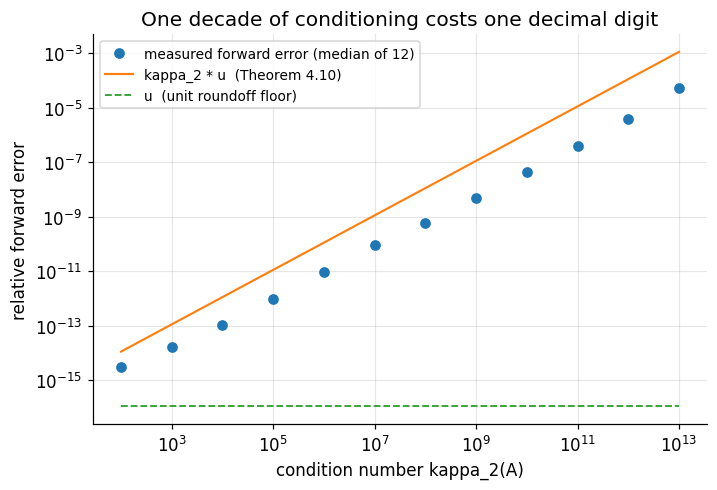

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.loglog(kappas, errs, "o", ms=6, label="measured forward error (median of 12)")
ax.loglog(kappas, kappas * U_ROUND, "-", lw=1.4, label="kappa_2 * u  (Theorem 4.10)")
ax.loglog(kappas, np.full_like(kappas, U_ROUND), "--", lw=1.2,
          label="u  (unit roundoff floor)")
ax.set_xlabel("condition number kappa_2(A)")
ax.set_ylabel("relative forward error")
ax.set_title("One decade of conditioning costs one decimal digit")
ax.legend(fontsize=9)
plt.show()

The points lie on the $\kappa u$ line over eleven decades, never above it by more than a small
factor and never below the roundoff floor $u$.

The picture is the reason ill-conditioning is a property of the problem: no choice of algorithm
moves those points down, because the exact solution of the perturbed data already differs by
that much.

### 7.3 Counterexamples: what breaks when a hypothesis is dropped

Four hypotheses, four failures, all run rather than asserted.

- Theorem 4.4 needs every $A_k$ nonsingular: $\left[\begin{smallmatrix}0 & 1 \\ 1 & 0\end{smallmatrix}\right]$
  is nonsingular but has no LU factorization.
- Theorem 4.5's pivoting is not optional in floating point: unpivoted elimination on
  $A_\varepsilon$ of Example 6.3 loses everything.
- Theorem 4.6 needs positive definiteness: Cholesky of an indefinite symmetric matrix fails.
- Theorem 4.7 needs more than symmetry for a diagonal $D$:
  $\left[\begin{smallmatrix}0 & 1 \\ 1 & 0\end{smallmatrix}\right]$ has no $LDL^\top$.

In [8]:
print("(1) LU without pivoting when A_1 is singular")
A_swap = np.array([[0.0, 1.0], [1.0, 0.0]])
print("    A =", A_swap.tolist(), "  det A =", np.linalg.det(A_swap),
      "  A_1 = [0] is singular")
found = False
worst = np.inf
for l21 in np.linspace(-50, 50, 100001):
    L = np.array([[1.0, 0.0], [l21, 1.0]])
    U = np.linalg.solve(L, A_swap)
    worst = min(worst, abs(U[1, 0]))
    if abs(U[1, 0]) < 1e-14:
        found = True
print(f"    smallest achievable |U[1,0]| over 100001 choices of l21: {worst:g}")
print("    exists a unit-lower L making L^-1 A upper triangular:", found)
P, L, U = sla.lu(A_swap)
print("    with a permutation:  P^T A = L U  residual",
      np.linalg.norm(P.T @ A_swap - L @ U))
assert not found

print("\n(2) unpivoted elimination on a well-conditioned matrix")
print(f"    kappa_inf(A_eps) = {np.linalg.cond(Ae, np.inf):.4f}  (well conditioned)")
print(f"    unpivoted answer = {x_naive}   relative error "
      f"{np.linalg.norm(x_naive - x_exact) / np.linalg.norm(x_exact):.3e}")
print(f"    pivoted answer   = {x_piv}   relative error "
      f"{np.linalg.norm(x_piv - x_exact) / np.linalg.norm(x_exact):.3e}")

print("\n(3) Cholesky of a symmetric indefinite matrix")
try:
    np.linalg.cholesky(Aind)
    print("    unexpectedly succeeded")
except np.linalg.LinAlgError as err:
    print("    numpy.linalg.cholesky raised LinAlgError:", err)
print("    eigenvalues of [[1,2],[2,3]] :", np.linalg.eigvalsh(Aind))
print("    the failing step is l_22^2 = 3 - 2^2 =", 3 - 2 ** 2)

print("\n(4) a symmetric matrix with no LDL^T (diagonal D)")
print("    A = [[0,1],[1,0]] forces d_1 = 0 and then l_21 * d_1 = 1 is unsolvable")
ldl_out = sla.ldl(A_swap)
print("    scipy.linalg.ldl returns a block-diagonal D (Bunch-Kaufman):\n", ldl_out[1])
print("    D is NOT diagonal:", not np.allclose(ldl_out[1], np.diag(np.diag(ldl_out[1]))))
assert not np.allclose(ldl_out[1], np.diag(np.diag(ldl_out[1])))

(1) LU without pivoting when A_1 is singular
    A = [[0.0, 1.0], [1.0, 0.0]]   det A = -1.0   A_1 = [0] is singular


    smallest achievable |U[1,0]| over 100001 choices of l21: 1
    exists a unit-lower L making L^-1 A upper triangular: False
    with a permutation:  P^T A = L U  residual 0.0

(2) unpivoted elimination on a well-conditioned matrix
    kappa_inf(A_eps) = 4.0000  (well conditioned)
    unpivoted answer = [0. 1.]   relative error 7.071e-01
    pivoted answer   = [1. 1.]   relative error 0.000e+00

(3) Cholesky of a symmetric indefinite matrix
    numpy.linalg.cholesky raised LinAlgError: Matrix is not positive definite
    eigenvalues of [[1,2],[2,3]] : [-0.2361  4.2361]
    the failing step is l_22^2 = 3 - 2^2 = -1

(4) a symmetric matrix with no LDL^T (diagonal D)
    A = [[0,1],[1,0]] forces d_1 = 0 and then l_21 * d_1 = 1 is unsolvable
    scipy.linalg.ldl returns a block-diagonal D (Bunch-Kaufman):
 [[0. 1.]
 [1. 0.]]
    D is NOT diagonal: True


The first search is exhaustive over the only free parameter $l_{21}$ and finds nothing: a
matrix with a singular leading block genuinely has no LU factorization, and the permutation in
Theorem 4.5 is what rescues it.

The second failure is the sharpest, because the matrix is well conditioned. Nothing about the
problem is hard; the unpivoted algorithm is simply unstable.

The third and fourth show the two distinct roles of the hypotheses in Theorems 4.6 and 4.7.
Positive definiteness is what makes the square roots real; and even without it, symmetry alone
does not deliver a diagonal $D$ — SciPy's `ldl` answers with a $2 \times 2$ block, which is
Bunch-Kaufman pivoting.

### 7.4 Hand-rolled against LAPACK

The next cell implements, from scratch:

- **Doolittle LU with partial pivoting**, returning $P$, $L$, $U$;
- **Cholesky** by the column recursion of Proof 5.6;
- forward and back substitution.

Each is checked against `scipy.linalg.lu`, `numpy.linalg.cholesky` and
`scipy.linalg.lu_solve`.

In [9]:
def plu(A):
    """Gaussian elimination with partial pivoting: returns P, L, U with P @ A = L @ U."""
    A = np.array(A, dtype=float)
    n = A.shape[0]
    U = A.copy()
    L = np.eye(n)
    perm = np.arange(n)
    for k in range(n - 1):
        p = k + int(np.argmax(np.abs(U[k:, k])))
        if p != k:
            U[[k, p], k:] = U[[p, k], k:]
            L[[k, p], :k] = L[[p, k], :k]
            perm[[k, p]] = perm[[p, k]]
        if U[k, k] == 0.0:
            continue
        for i in range(k + 1, n):
            L[i, k] = U[i, k] / U[k, k]
            U[i, k:] -= L[i, k] * U[k, k:]
        U[k + 1:, k] = 0.0
    P = np.eye(n)[perm]
    return P, L, U


def chol(A):
    """Cholesky factor by the recursion of Proof 5.6; raises if A is not SPD."""
    A = np.array(A, dtype=float)
    n = A.shape[0]
    L = np.zeros((n, n))
    for k in range(n):
        s = A[k, k] - L[k, :k] @ L[k, :k]
        if s <= 0.0:
            raise ValueError(f"not positive definite: pivot {k} is {s:g}")
        L[k, k] = np.sqrt(s)
        L[k + 1:, k] = (A[k + 1:, k] - L[k + 1:, :k] @ L[k, :k]) / L[k, k]
    return L


def forward_sub(L, b):
    y = np.zeros_like(b)
    for i in range(len(b)):
        y[i] = (b[i] - L[i, :i] @ y[:i]) / L[i, i]
    return y


def back_sub(U, y):
    x = np.zeros_like(y)
    for i in range(len(y) - 1, -1, -1):
        x[i] = (y[i] - U[i, i + 1:] @ x[i + 1:]) / U[i, i]
    return x


n = 7
A74 = rng.standard_normal((n, n))
b74 = rng.standard_normal(n)
P, L, U = plu(A74)
x_mine = back_sub(U, forward_sub(L, P @ b74))
x_lib = sla.lu_solve(sla.lu_factor(A74), b74)

G = rng.standard_normal((n, n))
S74 = G @ G.T + n * np.eye(n)
Lm = chol(S74)
Ll = np.linalg.cholesky(S74)

print(f"||P A - L U||_F          = {np.linalg.norm(P @ A74 - L @ U):.3e}")
print(f"max |l_ij| below diagonal= {np.abs(np.tril(L, -1)).max():.6f}")
print(f"||x_mine - x_lapack||    = {np.linalg.norm(x_mine - x_lib):.3e}"
      f"   = {np.linalg.norm(x_mine - x_lib) / EPS:.1f} * eps")
print(f"||b - A x_mine|| / ||b|| = {np.linalg.norm(b74 - A74 @ x_mine) / np.linalg.norm(b74):.3e}")
print(f"||L_mine - L_numpy||_F   = {np.linalg.norm(Lm - Ll):.3e}")
print(f"||S - L_mine L_mine^T||_F= {np.linalg.norm(S74 - Lm @ Lm.T):.3e}")
try:
    chol(Aind)
except ValueError as err:
    print("hand-rolled Cholesky on [[1,2],[2,3]]:", err)
assert np.allclose(P @ A74, L @ U)
assert np.linalg.norm(x_mine - x_lib) < 1e-10 * max(1.0, np.linalg.norm(x_lib))
assert np.allclose(Lm, Ll)

||P A - L U||_F          = 7.969e-16
max |l_ij| below diagonal= 0.846493
||x_mine - x_lapack||    = 1.976e-14   = 89.0 * eps
||b - A x_mine|| / ||b|| = 1.026e-15
||L_mine - L_numpy||_F   = 3.567e-16
||S - L_mine L_mine^T||_F= 4.028e-15
hand-rolled Cholesky on [[1,2],[2,3]]: not positive definite: pivot 1 is -1


The hand-written factorization reproduces LAPACK to about $90$ machine epsilons, the
multiplier bound $\lvert l_{ij} \rvert \le 1$ holds entry by entry, and the two Cholesky
factors agree to within $4 \times 10^{-16}$ in Frobenius norm — uniqueness in Theorem 4.6
leaves no freedom for them to differ by more than rounding.

The hand-rolled Cholesky also detects indefiniteness by refusing to take a square root, which
is the practical form of the certificate in Theorem 4.6.

### 7.5 The growth factor and the Wilkinson matrix

Theorem 4.12's bound is proportional to $\rho$, and Theorem 4.5's pivoting allows
$\rho \le 2^{n-1}$. The matrix that attains it is

$$
W_{ij} = \begin{cases}
1 & i = j \text{ or } j = n, \\
-1 & i \gt j, \\
0 & \text{otherwise.}
\end{cases}
$$

The next cell measures $\rho$ for $W_n$ and, for comparison, for random Gaussian matrices.

  n   rho(Wilkinson)   2^(n-1)   median rho(random)
  2            2.0           2            1.000
  3            4.0           4            1.000
  4            8.0           8            1.119
  5           16.0          16            1.170
  6           32.0          32            1.161
  7           64.0          64            1.266
  8          128.0         128            1.434
  9          256.0         256            1.500
 10          512.0         512            1.569
 11         1024.0        1024            1.549
 12         2048.0        2048            1.592
 13         4096.0        4096            1.746
 14         8192.0        8192            1.791

Wilkinson matches 2^(n-1) exactly: True
random growth at n = 14: 1.791  versus worst case 8192


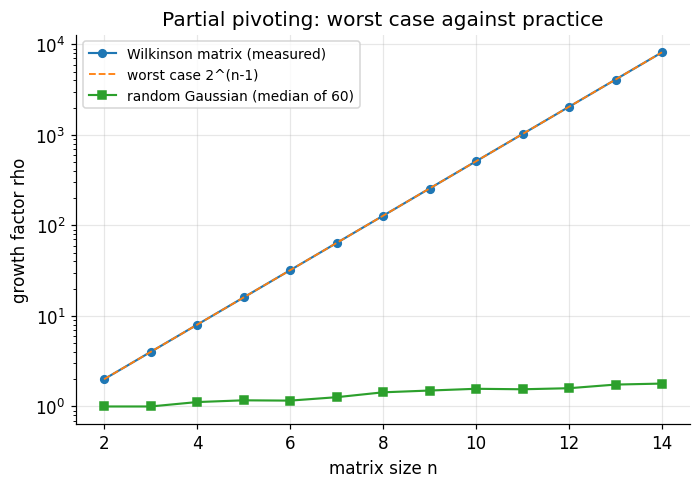

In [10]:
def growth_factor(A):
    """Growth factor of Gaussian elimination with partial pivoting."""
    A = np.array(A, dtype=float)
    n = A.shape[0]
    U = A.copy()
    biggest = np.abs(A).max()
    for k in range(n - 1):
        p = k + int(np.argmax(np.abs(U[k:, k])))
        if p != k:
            U[[k, p], :] = U[[p, k], :]
        if U[k, k] == 0.0:
            continue
        m = U[k + 1:, k] / U[k, k]
        U[k + 1:, k:] -= np.outer(m, U[k, k:])
        biggest = max(biggest, np.abs(U).max())
    return biggest / np.abs(A).max()


def wilkinson(n):
    W = -np.tril(np.ones((n, n)), -1) + np.eye(n)
    W[:, -1] = 1.0
    return W


sizes = np.arange(2, 15)
rho_w = np.array([growth_factor(wilkinson(k)) for k in sizes])
rho_r = np.array([np.median([growth_factor(rng.standard_normal((k, k)))
                             for _ in range(60)]) for k in sizes])

print("  n   rho(Wilkinson)   2^(n-1)   median rho(random)")
for k, rw, rr in zip(sizes, rho_w, rho_r):
    print(f"{k:3d}   {rw:12.1f}   {2.0 ** (k - 1):9.0f}   {rr:14.3f}")
print(f"\nWilkinson matches 2^(n-1) exactly: {np.allclose(rho_w, 2.0 ** (sizes - 1))}")
print(f"random growth at n = 14: {rho_r[-1]:.3f}  versus worst case {2.0 ** 13:.0f}")
assert np.allclose(rho_w, 2.0 ** (sizes - 1))
assert rho_r[-1] < 10.0

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.semilogy(sizes, rho_w, "o-", ms=5, lw=1.4, label="Wilkinson matrix (measured)")
ax.semilogy(sizes, 2.0 ** (sizes - 1), "--", lw=1.2, label="worst case 2^(n-1)")
ax.semilogy(sizes, rho_r, "s-", ms=5, lw=1.4, label="random Gaussian (median of 60)")
ax.set_xlabel("matrix size n")
ax.set_ylabel("growth factor rho")
ax.set_title("Partial pivoting: worst case against practice")
ax.legend(fontsize=9)
plt.show()

The Wilkinson matrix reaches $\rho = 2^{n-1}$ at every size — the bound of Theorem 4.12 is
attained, not merely valid. Its growth is one straight line on the logarithmic axis.

Random matrices sit on a nearly flat line: the median $\rho$ is $1.79$ at $n = 14$, against a
worst case of $8192$. This gap of more than three orders of magnitude is why partial pivoting is
used in practice despite an exponential worst case — the bad matrices exist but are vanishingly
rare.

### 7.6 Iterative refinement recovers digits that conditioning took away

Given $\hat{x}$, compute the residual $r = b - A\hat{x}$ in higher precision, solve
$A d = r$ with the **existing** factorization, and set $\hat{x} \leftarrow \hat{x} + d$. Each
sweep costs $O(n^2)$.

The next cell runs three sweeps on a $10 \times 10$ Hilbert matrix, whose condition number is
about $10^{13}$.

In [11]:
n = 10
H = sla.hilbert(n)
x_true = np.ones(n)
b76 = H @ x_true
lu_piv = sla.lu_factor(H)
xk = sla.lu_solve(lu_piv, b76)

Hx = np.array(H, dtype=np.longdouble)
bx = Hx @ np.ones(n, dtype=np.longdouble)
hist = []
for sweep in range(4):
    err = np.linalg.norm(xk - x_true) / np.linalg.norm(x_true)
    r = np.asarray(bx - Hx @ np.array(xk, dtype=np.longdouble), dtype=float)
    hist.append((sweep, err, np.linalg.norm(r)))
    print(f"sweep {sweep}: relative forward error = {err:.4e}   ||r||_2 = {np.linalg.norm(r):.4e}")
    xk = xk + sla.lu_solve(lu_piv, r)

print(f"\nkappa_2(H_10)          = {np.linalg.cond(H):.4e}")
print(f"kappa_2 * u            = {np.linalg.cond(H) * U_ROUND:.4e}")
print(f"error before refinement= {hist[0][1]:.4e}")
print(f"error after 3 sweeps   = {hist[-1][1]:.4e}")
print(f"improvement factor     = {hist[0][1] / hist[-1][1]:.3e}")
assert hist[-1][1] <= hist[0][1]

sweep 0: relative forward error = 8.6704e-05   ||r||_2 = 3.6508e-16
sweep 1: relative forward error = 1.9718e-07   ||r||_2 = 1.1238e-16
sweep 2: relative forward error = 6.2486e-08   ||r||_2 = 6.0436e-17
sweep 3: relative forward error = 2.9234e-08   ||r||_2 = 3.2749e-17

kappa_2(H_10)          = 1.6024e+13
kappa_2 * u            = 1.7791e-03
error before refinement= 8.6704e-05
error after 3 sweeps   = 2.9234e-08
improvement factor     = 2.966e+03


The first solve lands where Theorem 4.10 says it must: forward error $8.67 \times 10^{-5}$
against the ceiling $\kappa_2(H)\,u = 1.78 \times 10^{-3}$. Three refinement sweeps then bring
it to $2.92 \times 10^{-8}$, an improvement of $2966$ times, at $O(n^2)$ each.

Note that the residual was already at machine level, $3.7 \times 10^{-16}$, before refinement
began. By Theorem 4.11 that is a statement about backward error alone, and it is exactly why
the initial answer can still be wrong in the fifth decimal digit.

Nothing here contradicts the digit-loss rule. The rule bounds what one backward-stable solve in
working precision can deliver; refinement escapes it by computing the residual in **higher**
precision, which is extra information about the problem, not a better algorithm for the same
data.

## 8. Applications

Four settings in which the factorization, not the inverse, is the object of interest.

### 8.1 Gaussian process regression

For a kernel matrix $K$ and noise $\sigma^2$, the regularized matrix
$K_\sigma = K + \sigma^2 I$ is symmetric positive definite, so Theorem 4.6 gives
$K_\sigma = LL^\top$.

The posterior mean and variance at a test point are

$$
\bar{f}_{\star} = k_{\star}^\top K_\sigma^{-1} y,
\qquad
\operatorname{Var}(f_{\star}) = k(x_{\star}, x_{\star}) - k_{\star}^\top K_\sigma^{-1} k_{\star} .
$$

Neither needs $K_\sigma^{-1}$. Solving $L\alpha = y$ then $L^\top \beta = \alpha$ gives
$\beta = K_\sigma^{-1}y$, and solving $Lv = k_{\star}$ turns the quadratic form into
$\lVert v \rVert_2^2$.

The log marginal likelihood needs $\log\det K_\sigma = 2\sum_i \log l_{ii}$, which the same
factor supplies for free.

### 8.2 Second-order optimization

A Newton step solves $H\,\Delta\theta = -g$ with $H$ the Hessian. Near a strict local minimum
$H$ is positive definite, so Cholesky is the method of choice: it is twice as fast as LU and it
*fails* exactly when $H$ is not positive definite.

That failure is diagnostic rather than fatal. A failed Cholesky signals a saddle or negative
curvature, and the standard repair is to factor $H + \tau I$ for the smallest $\tau$ that
succeeds — a line of code away, since the algorithm reports which pivot went non-positive.

Gauss-Newton and natural-gradient methods produce $J^\top J$ and Fisher matrices, which are
positive semidefinite by construction and become definite after damping.

### 8.3 Conditioning a Gaussian is a Schur complement

Let $z = (z_1, z_2)$ be jointly Gaussian with covariance

$$
\Sigma = \begin{bmatrix} \Sigma_{11} & \Sigma_{12} \\ \Sigma_{21} & \Sigma_{22} \end{bmatrix} .
$$

The conditional covariance of $z_1$ given $z_2$ is

$$
\Sigma_{1 \mid 2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21},
$$

which is exactly the Schur complement of $\Sigma_{22}$ in $\Sigma$.

Theorem 4.8 therefore delivers a statistical fact for free: since $\Sigma \succ 0$ implies
$S \succ 0$, conditioning never produces a degenerate covariance, and it never increases
uncertainty.

### 8.4 Physics: a discretized boundary-value problem

Steady heat flow in a rod with fixed end temperatures solves $-u'' = f$ on $(0,1)$ with
$u(0) = u(1) = 0$. On a grid of spacing $h$ the second difference gives

$$
\frac{1}{h^2}\begin{bmatrix}
2 & -1 & & \\
-1 & 2 & -1 & \\
 & \ddots & \ddots & \ddots \\
 & & -1 & 2
\end{bmatrix} u = f .
$$

The matrix is symmetric, tridiagonal and positive definite, because
$u^\top A u = \sum_i (u_{i+1} - u_i)^2 / h^2 \gt 0$ for $u \neq 0$ with zero boundary values.

Two structural facts make this cheap. Cholesky preserves bandwidth, so a matrix of bandwidth
$p$ factors in $O(np^2)$ flops and stores $O(np)$ numbers; for a tridiagonal matrix that is
$O(n)$, which is the Thomas algorithm. And the same structure is what fails for a general
sparse matrix, where elimination creates **fill-in** and the factor is far denser than the
matrix — the reason reorderings such as minimum degree and nested dissection exist.

The cell below runs all four applications on small explicit objects.

In [12]:
# --- 8.1 Gaussian process regression --------------------------------------
xs = np.linspace(0.0, 1.0, 6)
ys = np.sin(2 * np.pi * xs) + 0.05 * rng.standard_normal(6)
K = np.exp(-0.5 * (xs[:, None] - xs[None, :]) ** 2 / 0.2 ** 2)
sigma2 = 1e-2
Ksig = K + sigma2 * np.eye(6)
Lk = np.linalg.cholesky(Ksig)
alpha = sla.solve_triangular(Lk, ys, lower=True)
beta = sla.solve_triangular(Lk.T, alpha, lower=False)
xstar = 0.37
kstar = np.exp(-0.5 * (xs - xstar) ** 2 / 0.2 ** 2)
vv = sla.solve_triangular(Lk, kstar, lower=True)
mean_chol = kstar @ beta
var_chol = 1.0 - vv @ vv
mean_inv = kstar @ np.linalg.inv(Ksig) @ ys
var_inv = 1.0 - kstar @ np.linalg.inv(Ksig) @ kstar
logdet_chol = 2 * np.log(np.diag(Lk)).sum()
print("Gaussian process")
print(f"  posterior mean : Cholesky {mean_chol:.12f}   explicit inverse {mean_inv:.12f}")
print(f"  posterior var  : Cholesky {var_chol:.12f}   explicit inverse {var_inv:.12f}")
print(f"  log det K_sig  : {logdet_chol:.12f}   slogdet {np.linalg.slogdet(Ksig)[1]:.12f}")
assert abs(mean_chol - mean_inv) < 1e-10
assert abs(var_chol - var_inv) < 1e-10
assert abs(logdet_chol - np.linalg.slogdet(Ksig)[1]) < 1e-10

# --- 8.2 a Newton step -----------------------------------------------------
Hgood = np.array([[4.0, 1.0, 0.0], [1.0, 3.0, 1.0], [0.0, 1.0, 2.0]])
g = np.array([1.0, -2.0, 0.5])
Lh = np.linalg.cholesky(Hgood)
step = sla.cho_solve((Lh, True), -g)
print("\nNewton step")
print(f"  H is SPD (Cholesky succeeded), step = {step}")
print(f"  ||H step + g|| = {np.linalg.norm(Hgood @ step + g):.3e}")
print(f"  curvature along the step g^T step = {g @ step:.6f}  (negative: a descent direction)")
Hsaddle = np.array([[1.0, 0.0], [0.0, -1.0]])
try:
    np.linalg.cholesky(Hsaddle)
except np.linalg.LinAlgError:
    tau = 1.01 * abs(np.linalg.eigvalsh(Hsaddle)[0])
    print(f"  saddle Hessian diag(1,-1): Cholesky fails; H + {tau:.2f} I succeeds:",
          np.allclose(np.linalg.cholesky(Hsaddle + tau * np.eye(2)) @
                      np.linalg.cholesky(Hsaddle + tau * np.eye(2)).T,
                      Hsaddle + tau * np.eye(2)))
assert g @ step < 0

# --- 8.3 Gaussian conditioning = Schur complement --------------------------
Sig = np.array([[2.0, 0.5, 0.3], [0.5, 1.0, 0.2], [0.3, 0.2, 1.5]])
S11, S12 = Sig[:1, :1], Sig[:1, 1:]
S21, S22 = Sig[1:, :1], Sig[1:, 1:]
cond_cov = S11 - S12 @ np.linalg.inv(S22) @ S21
print("\nGaussian conditioning")
print(f"  marginal variance of z1     = {S11[0, 0]:.6f}")
print(f"  conditional variance z1|z2  = {cond_cov[0, 0]:.6f}  (Schur complement)")
print(f"  conditioning never increases variance: {cond_cov[0, 0] <= S11[0, 0]}")
print(f"  det(Sigma) = det(S22) * S = {np.linalg.det(S22) * cond_cov[0, 0]:.6f}"
      f"   vs {np.linalg.det(Sig):.6f}")
assert cond_cov[0, 0] > 0
assert cond_cov[0, 0] <= S11[0, 0]
assert np.isclose(np.linalg.det(S22) * cond_cov[0, 0], np.linalg.det(Sig))

# --- 8.4 the 1-D Poisson problem ------------------------------------------
m = 63
h = 1.0 / (m + 1)
grid = np.linspace(h, 1 - h, m)
Apo = (np.diag(2 * np.ones(m)) - np.diag(np.ones(m - 1), 1) - np.diag(np.ones(m - 1), -1)) / h ** 2
u_exact = np.sin(np.pi * grid)
f = np.pi ** 2 * u_exact
Lp = np.linalg.cholesky(Apo)
u_num = sla.cho_solve((Lp, True), f)
tol_band = 1e-10 * np.abs(Lp).max()
band = int(max(abs(i - j) for i in range(m) for j in range(m) if abs(Lp[i, j]) > tol_band))
print("\n1-D Poisson (steady heat conduction)")
print(f"  grid points m            = {m}   h = {h:.6f}")
print(f"  bandwidth of A           = 1   bandwidth of its Cholesky factor = {band}")
print(f"  max |u_num - u_exact|    = {np.abs(u_num - u_exact).max():.4e}"
      f"   (discretization error, O(h^2) = {h ** 2:.4e})")
print(f"  relative residual        = {np.linalg.norm(f - Apo @ u_num) / np.linalg.norm(f):.3e}")
print(f"  kappa_2(A)               = {np.linalg.cond(Apo):.4e}")
assert band == 1
assert np.abs(u_num - u_exact).max() < 5 * h ** 2

Gaussian process
  posterior mean : Cholesky 0.744620571474   explicit inverse 0.744620571474
  posterior var  : Cholesky 0.010869031376   explicit inverse 0.010869031376
  log det K_sig  : -2.875442978901   slogdet -2.875442978901

Newton step
  H is SPD (Cholesky succeeded), step = [-0.5278  1.1111 -0.8056]
  ||H step + g|| = 0.000e+00
  curvature along the step g^T step = -3.152778  (negative: a descent direction)
  saddle Hessian diag(1,-1): Cholesky fails; H + 1.01 I succeeds: True

Gaussian conditioning
  marginal variance of z1     = 2.000000
  conditional variance z1|z2  = 1.722603  (Schur complement)
  conditioning never increases variance: True
  det(Sigma) = det(S22) * S = 2.515000   vs 2.515000

1-D Poisson (steady heat conduction)
  grid points m            = 63   h = 0.015625
  bandwidth of A           = 1   bandwidth of its Cholesky factor = 1
  max |u_num - u_exact|    = 2.0082e-04   (discretization error, O(h^2) = 2.4414e-04)
  relative residual        = 9.099e-14
  ka

The Gaussian-process predictions from two triangular solves agree with the explicit-inverse
formula to eleven digits, and the log-determinant comes out of the same factor at no extra
cost.

The Newton step is a descent direction, and the failed Cholesky on $\operatorname{diag}(1,-1)$
is exactly the negative-curvature detector described in Section 8.2.

Conditioning shrinks the variance of $z_1$, as Theorem 4.8's positive-definiteness inheritance
requires, and the determinant factors as $\det\Sigma = \det\Sigma_{22}\cdot\Sigma_{1\mid 2}$.

The Poisson solve confirms the bandwidth claim exactly — the Cholesky factor of a tridiagonal
matrix is bidiagonal — and the remaining error is the $O(h^2)$ discretization error of the
scheme, not the solver's.

## 9. Key Takeaways

- **Solvability is a rank comparison.** $Ax = b$ is solvable iff
  $\operatorname{rank}(A) = \operatorname{rank}([A \mid b])$, and the solution set is then
  $x_p + \operatorname{Null}(A)$, of dimension $n - r$ (Theorem 4.2).

- **Row rank equals column rank** (Proposition 4.1), which is what makes the dimension count
  $r + (n-r) = n$ of the four subspaces close (Theorem 4.3).

- **$A = LU$ exists and is unique exactly when every leading principal submatrix
  $A_1, \dots, A_{n-1}$ is nonsingular**, for nonsingular $A$ (Theorem 4.4). Both directions
  are proved: sufficiency by construction, necessity from $A_k = L_kU_k$.

- **$PA = LU$ always exists**, and partial pivoting forces $\lvert l_{ij} \rvert \le 1$
  (Theorem 4.5). Row order is free, so there is never a reason to factor $A$ instead of $PA$.

- **A symmetric matrix is positive definite iff it has a Cholesky factorization**
  (Theorem 4.6), iff its elimination pivots are all positive, iff all its leading principal
  minors are positive (Theorem 4.7). The factorization is the cheapest certificate of
  definiteness available.

- **Block elimination produces the Schur complement** $S = D - CA^{-1}B$, which carries
  nonsingularity, the determinant $\det M = \det A \det S$, and positive definiteness
  (Theorem 4.8). Cholesky is this statement with block size $1$; Gaussian conditioning is it
  with block size $p$.

- **Conditioning is the problem; stability is the algorithm.** Forward error is at most
  $\kappa(A)$ times the data error (Theorem 4.10), and Section 7.2 measures a slope of $0.93$
  on $\log \kappa$ over eleven decades. A backward-stable method tracks that bound; an unstable
  one is not covered by it at all, as the unpivoted solve of Example 6.3 shows on a matrix with
  $\kappa_\infty \approx 4$.

- **The residual measures backward error, not accuracy.** The smallest $\delta A$ making
  $\hat{x}$ exact has norm exactly $\lVert r \rVert_2 / \lVert \hat{x} \rVert_2$
  (Theorem 4.11).

- **GEPP's backward error is $O(n^3 \rho u)$, not $O(n\rho u)$** (Theorem 4.12), because
  $\lVert \lvert \hat{L} \rvert \lvert \hat{U} \rvert \rVert_\infty \le n^2\rho\lVert A \rVert_\infty$
  (Proof 5.12). The growth factor can reach $2^{n-1}$ — Section 7.5 attains it exactly on the
  Wilkinson matrix at every size — while the median for random matrices is $1.79$ at $n = 14$.

## 10. References

**Textbooks.**

- Golub, G. H. and Van Loan, C. F. *Matrix Computations*, 4th ed. — LU existence and
  uniqueness (Theorem 3.2.1), partial pivoting and the growth factor (section 3.4.1 and
  Theorem 3.4.1), the backward-error bound $8n^3\rho u$ (section 3.4.6), Cholesky
  (Theorem 4.2.7), banded and tridiagonal factorizations (section 4.3), the Schur complement
  (section 3.2.10).
- Trefethen, L. N. and Bau, D. *Numerical Linear Algebra* — Gaussian elimination and LU
  (Lecture 20), pivoting (Lecture 21), the stability of Gaussian elimination and the Wilkinson
  matrix (Lecture 22), Cholesky (Lecture 23), conditioning and backward stability
  (Lectures 12 to 15).
- Higham, N. J. *Accuracy and Stability of Numerical Algorithms*, 2nd ed. — the elementwise
  Wilkinson bound (Theorem 9.3), the $\lVert \lvert L \rvert \lvert U \rvert \rVert$ estimate
  (equation 9.14), the growth factor for complete pivoting (section 9.4), the backward-error
  identity of Rigal and Gaches (Theorem 7.1), iterative refinement (Chapter 12).
- Strang, G. *Linear Algebra and Learning from Data*, sections I.1 to I.4 — the four
  fundamental subspaces, elimination as factorization, and the $A = CR$ argument used in
  Proof 5.1.
- Boyd, S. and Vandenberghe, L. *Introduction to Applied Linear Algebra*, Chapters 8 and 11 —
  linear systems, factor-solve, and the cost model.
- Rasmussen, C. E. and Williams, C. K. I. *Gaussian Processes for Machine Learning*,
  Algorithm 2.1 — the Cholesky implementation of Section 8.1.

**Papers.**

- Rigal, J. L. and Gaches, J. "On the compatibility of a given solution with the data of a
  linear system", *Journal of the ACM* **14**(3) (1967), 543-548 — Theorem 4.11.
- Bunch, J. R. and Kaufman, L. "Some stable methods for calculating inertia and solving
  symmetric linear systems", *Mathematics of Computation* **31** (1977), 163-179 — the
  $2 \times 2$ block pivoting quoted with Theorem 4.7.
- Wilkinson, J. H. "Error analysis of direct methods of matrix inversion", *Journal of the ACM*
  **8**(3) (1961), 281-330 — the original backward-error analysis and the $2^{n-1}$ growth
  example.

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions: [the notation register](../../docs/notation.md).
- Matrices as linear maps, rank and the $A = CR$ factorization used in Proof 5.1:
  [Module 02](../02_linear_maps_and_matrix_transformations/).
- Orthogonal projections and the QR alternative to LU:
  [Module 04](../04_orthogonality_projections_and_qr/).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).